# House Price Prediction and Explanation - Comprehensive Analysis
# Ames, Iowa Housing Dataset

**Author:** Data Science Team  
**Date:** November 2025  
**Objective:** Build interpretable machine learning models to predict house prices and provide actionable insights through comprehensive data analysis, feature engineering, and explainability visualizations.

---

## Table of Contents
1. [Load and Inspect Data](#section1)
2. [Basic Column Profiling](#section2)
3. [Missing Value Analysis](#section3)
4. [Target Variable Analysis](#section4)
5. [Feature Relationships](#section5)
6. [Missing Value Treatment](#section6)
7. [Categorical Encoding](#section7)
8. [Feature Engineering](#section8)
9. [Feature Selection](#section9)
10. [Data Leakage Verification](#section10)

---

<a id="section1"></a>
## 1. Load and Inspect Data

Import all necessary libraries and load the dataset files.

In [52]:
# Import Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

# Statistical Analysis
from scipy import stats
from scipy.stats import skew, kurtosis, normaltest, probplot
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.feature_selection import mutual_info_regression, SelectKBest, RFE, f_regression
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Gradient Boosting
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Explainability
import shap

# Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import HeatMap

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"XGBoost version: {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")
print(f"SHAP version: {shap.__version__}")

✓ All libraries imported successfully!
Pandas version: 2.2.3
NumPy version: 2.1.3
XGBoost version: 3.1.2
LightGBM version: 4.6.0
SHAP version: 0.50.0


In [53]:
# Load datasets
data_path = Path('./dataset')

train_df = pd.read_csv(data_path / 'train.csv')
test_df = pd.read_csv(data_path / 'test.csv')
sample_submission = pd.read_csv(data_path / 'sample_submission.csv')

# Load data description
with open(data_path / 'data_description.txt', 'r') as f:
    data_description = f.read()

print("="*80)
print("DATASET LOADED SUCCESSFULLY")
print("="*80)
print(f"\nTrain Set Shape: {train_df.shape}")
print(f"Test Set Shape: {test_df.shape}")
print(f"Sample Submission Shape: {sample_submission.shape}")
print(f"\nTarget Variable: SalePrice")
print(f"Number of Features: {train_df.shape[1] - 1}")
print(f"Number of Training Samples: {train_df.shape[0]}")
print(f"Number of Test Samples: {test_df.shape[0]}")

# Display first few rows
print("\n" + "="*80)
print("FIRST 5 ROWS OF TRAINING DATA")
print("="*80)
train_df.head()

DATASET LOADED SUCCESSFULLY

Train Set Shape: (1460, 81)
Test Set Shape: (1459, 80)
Sample Submission Shape: (1459, 2)

Target Variable: SalePrice
Number of Features: 80
Number of Training Samples: 1460
Number of Test Samples: 1459

FIRST 5 ROWS OF TRAINING DATA


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [54]:
# Basic dataset information
print("="*80)
print("DATASET INFO")
print("="*80)
train_df.info()

print("\n" + "="*80)
print("BASIC STATISTICS FOR NUMERIC FEATURES")
print("="*80)
train_df.describe().T

DATASET INFO


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


<a id="section2"></a>
## 2. Basic Column Profiling

Identify data types and perform comprehensive distribution analysis for all features.

In [55]:
# Identify numeric and categorical columns
numeric_features = train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = train_df.select_dtypes(include=['object']).columns.tolist()

# Remove Id and SalePrice from features
if 'Id' in numeric_features:
    numeric_features.remove('Id')
if 'SalePrice' in numeric_features:
    numeric_features.remove('SalePrice')

print("="*80)
print("FEATURE TYPE CLASSIFICATION")
print("="*80)
print(f"\nNumeric Features ({len(numeric_features)}):")
print(numeric_features)
print(f"\nCategorical Features ({len(categorical_features)}):")
print(categorical_features)

# Create comprehensive feature profile
feature_profile = []

for col in train_df.columns:
    if col in ['Id', 'SalePrice']:
        continue
    
    profile = {
        'Feature': col,
        'Type': 'Numeric' if col in numeric_features else 'Categorical',
        'DType': str(train_df[col].dtype),
        'Missing_Count': train_df[col].isnull().sum(),
        'Missing_Pct': round(100 * train_df[col].isnull().sum() / len(train_df), 2),
        'Unique_Values': train_df[col].nunique(),
        'Cardinality': 'High' if train_df[col].nunique() > 20 else 'Medium' if train_df[col].nunique() > 10 else 'Low'
    }
    
    if col in numeric_features:
        profile['Mean'] = round(train_df[col].mean(), 2)
        profile['Median'] = round(train_df[col].median(), 2)
        profile['Std'] = round(train_df[col].std(), 2)
        profile['Min'] = round(train_df[col].min(), 2)
        profile['Max'] = round(train_df[col].max(), 2)
        profile['Skewness'] = round(train_df[col].skew(), 2)
        profile['Kurtosis'] = round(train_df[col].kurtosis(), 2)
    else:
        profile['Mode'] = train_df[col].mode()[0] if len(train_df[col].mode()) > 0 else None
        profile['Mode_Freq'] = train_df[col].value_counts().iloc[0] if len(train_df[col]) > 0 else 0
        profile['Mode_Pct'] = round(100 * train_df[col].value_counts().iloc[0] / len(train_df), 2) if len(train_df) > 0 else 0
    
    feature_profile.append(profile)

feature_profile_df = pd.DataFrame(feature_profile)
print("\n" + "="*80)
print("COMPREHENSIVE FEATURE PROFILE")
print("="*80)
feature_profile_df

FEATURE TYPE CLASSIFICATION

Numeric Features (36):
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']

Categorical Features (43):
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Fu

,Feature,Type,DType,Missing_Count,Missing_Pct,Unique_Values,Cardinality,Mean,Median,Std,Min,Max,Skewness,Kurtosis,Mode,Mode_Freq,Mode_Pct
0,MSSubClass,Numeric,int64,0,0.00,15,Medium,56.90,50.0,42.30,20.0,190.0,1.41,1.58,NaN,NaN,NaN
1,MSZoning,Categorical,object,0,0.00,5,Low,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RL,1151.0,78.84
2,LotFrontage,Numeric,float64,259,17.74,110,High,70.05,69.0,24.28,21.0,313.0,2.16,17.45,NaN,NaN,NaN
3,LotArea,Numeric,int64,0,0.00,1073,High,10516.83,9478.5,9981.26,1300.0,215245.0,12.21,203.24,NaN,NaN,NaN
4,Street,Categorical,object,0,0.00,2,Low,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pave,1454.0,99.59
5,Alley,Categorical,object,1369,93.77,2,Low,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Grvl,50.0,3.42
6,LotShape,Categorical,object,0,0.00,4,Low,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Reg,925.0,63.36
7,LandContour,Categorical,object,0,0.00,4,Low,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lvl,1311.0,89.79
8,Utilities,Categorical,object,0,0.00,2,Low,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AllPub,1459.0,99.93
9,LotConfig,Categorical,object,0,0.00,5,Low,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inside,1052.0,72.05


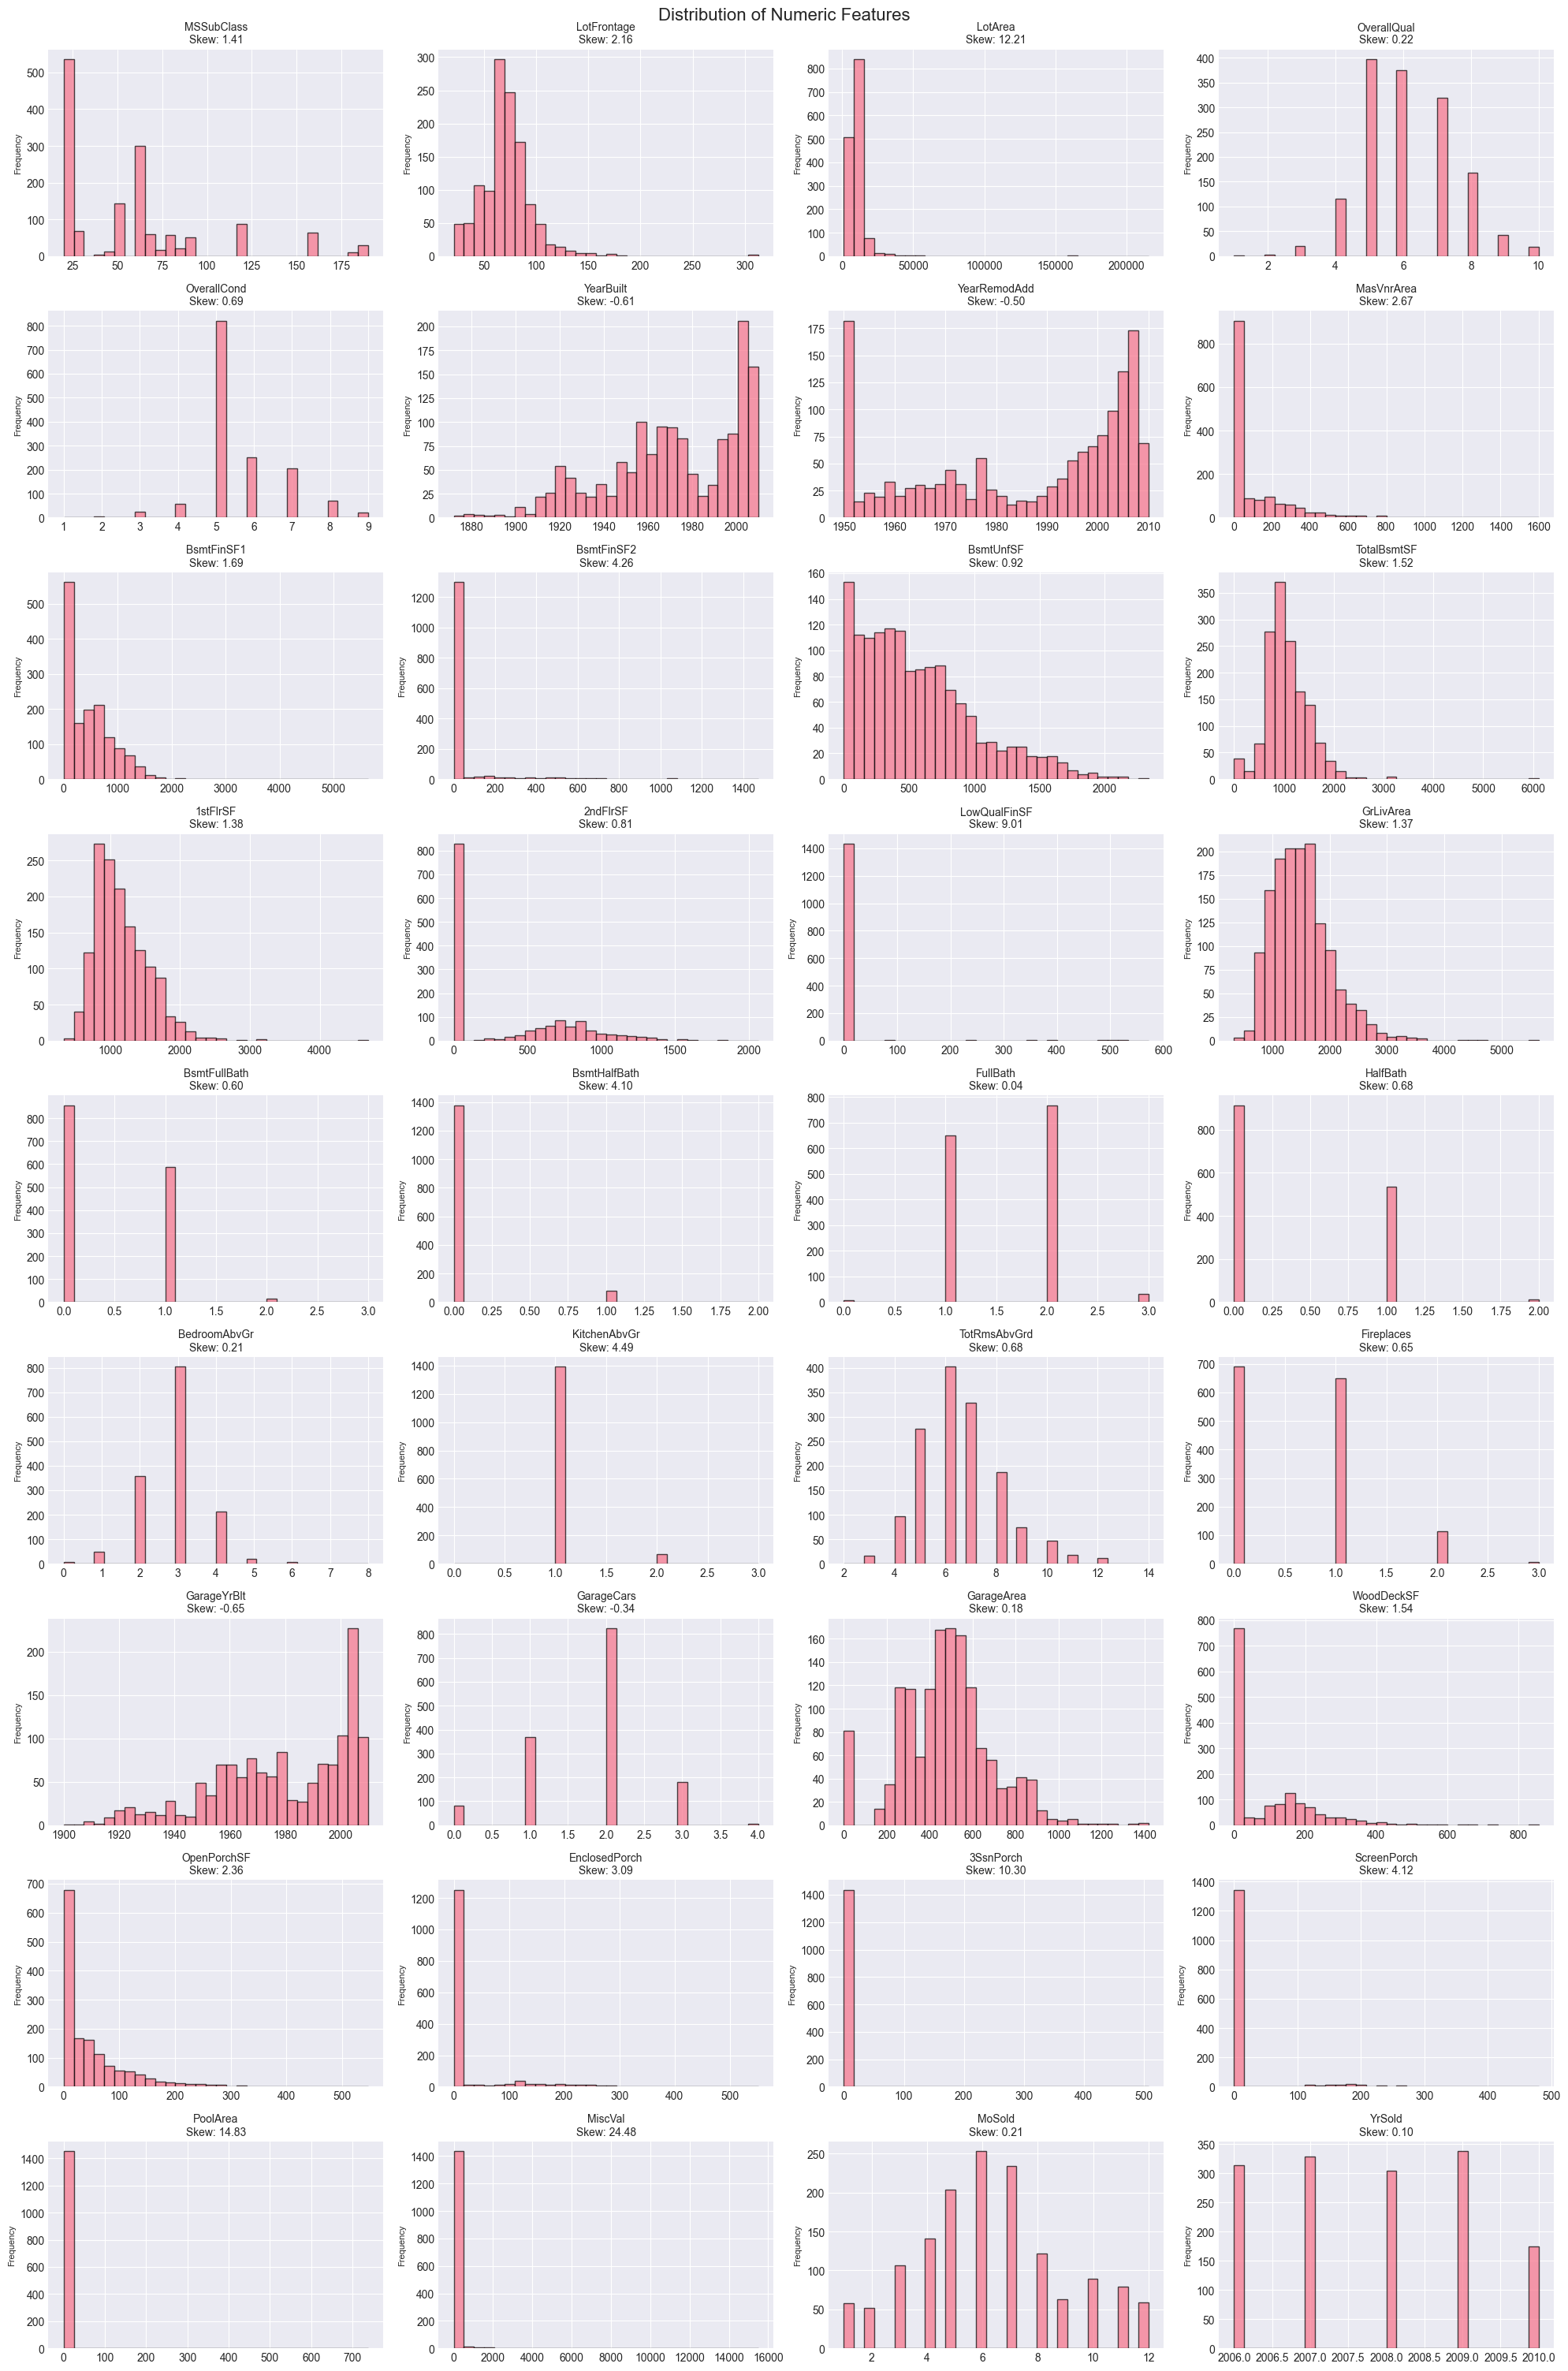

✓ Numeric feature distributions visualized


In [56]:
# Visualize distribution of numeric features
fig, axes = plt.subplots(nrows=9, ncols=4, figsize=(20, 30))
axes = axes.flatten()

for idx, col in enumerate(numeric_features[:36]):  # Plot first 36 numeric features
    if idx < len(axes):
        train_df[col].hist(bins=30, ax=axes[idx], edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col}\nSkew: {train_df[col].skew():.2f}', fontsize=10)
        axes[idx].set_xlabel('')
        axes[idx].set_ylabel('Frequency', fontsize=8)

# Hide unused subplots
for idx in range(len(numeric_features[:36]), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.suptitle('Distribution of Numeric Features', fontsize=16, y=1.001)
plt.show()

print("✓ Numeric feature distributions visualized")

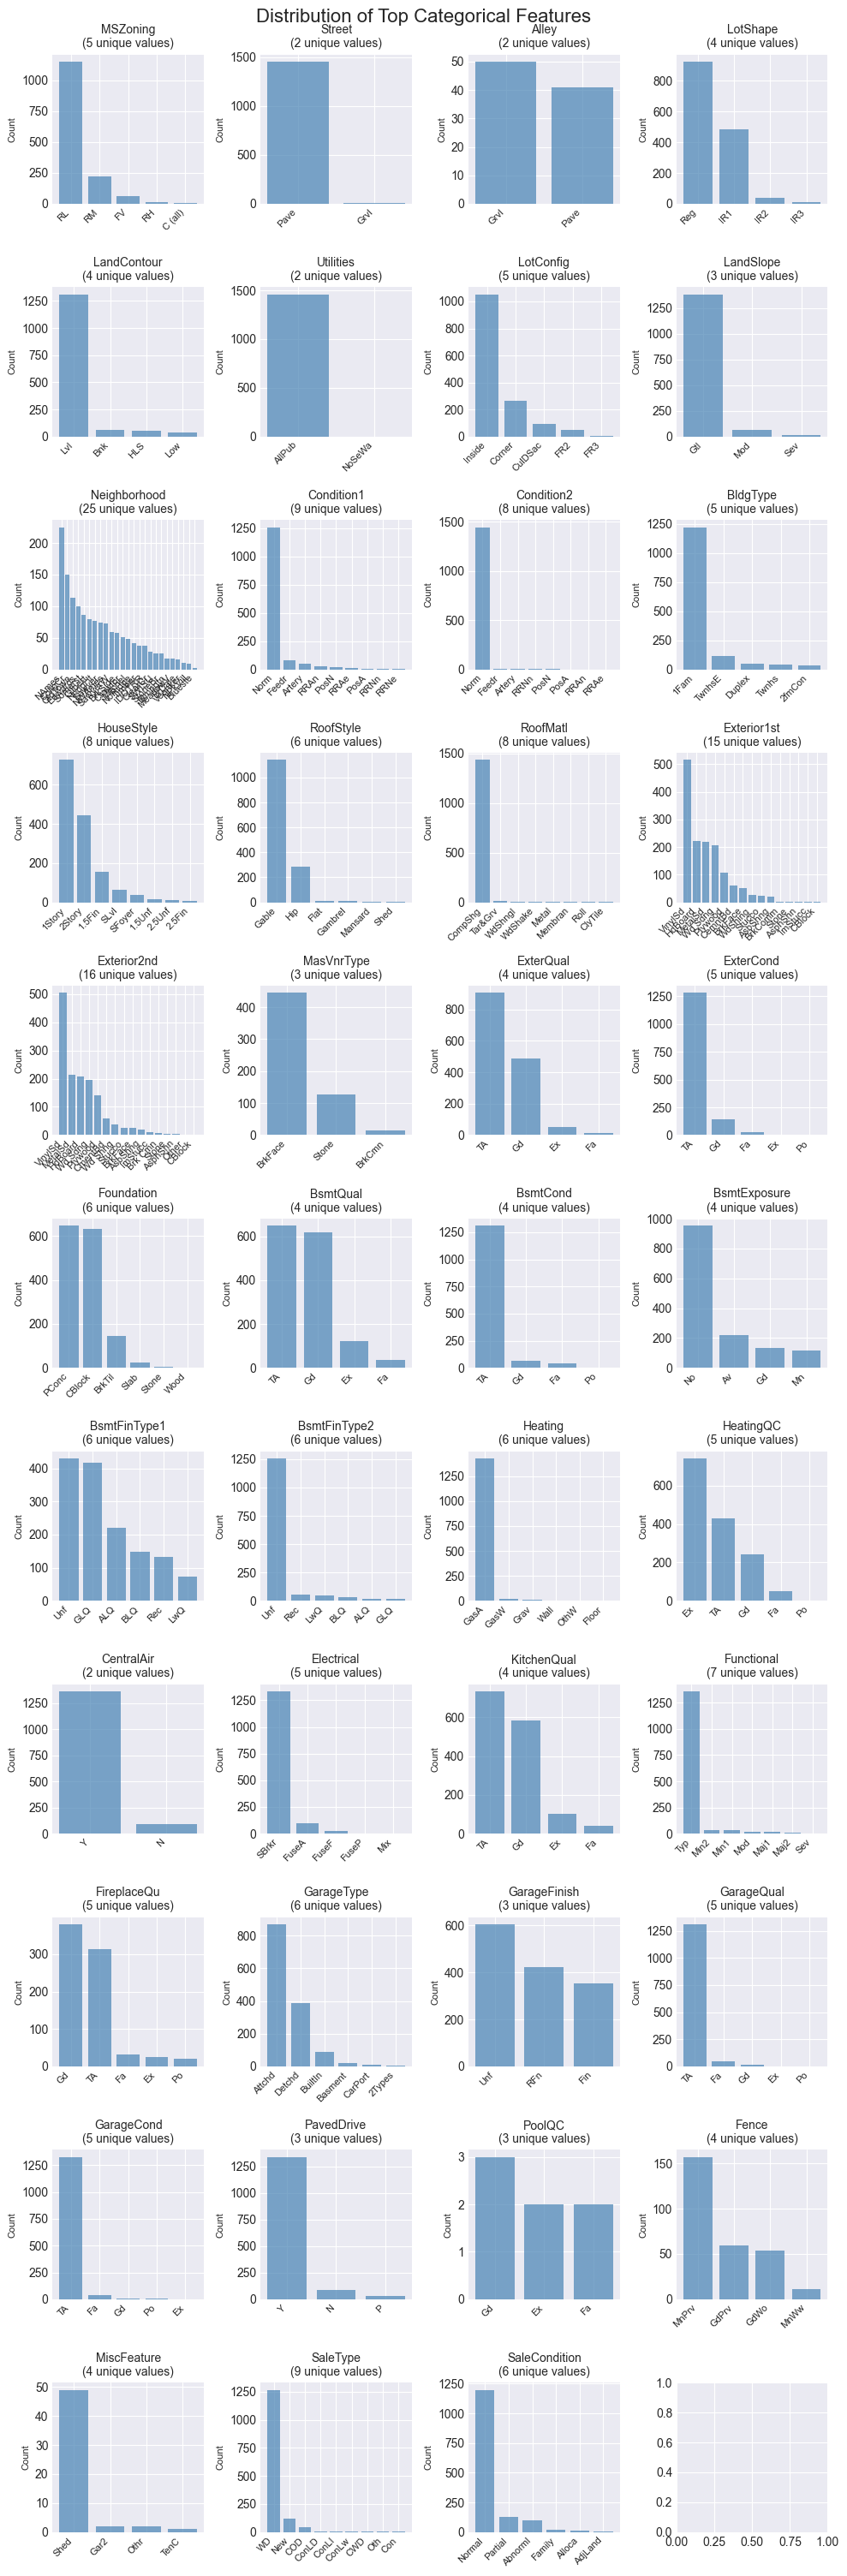

✓ Categorical feature distributions visualized


In [57]:
# Visualize top categorical features
top_categorical = categorical_features[:]  # First 12 categorical features

fig, axes = plt.subplots(nrows=11, ncols=4, figsize=(10, 30))
axes = axes.flatten()

for idx, col in enumerate(top_categorical):
    value_counts = train_df[col].value_counts()
    axes[idx].bar(range(len(value_counts)), value_counts.values, color='steelblue', alpha=0.7)
    axes[idx].set_title(f'{col}\n({train_df[col].nunique()} unique values)', fontsize=10)
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=8)
    axes[idx].set_ylabel('Count', fontsize=8)

plt.tight_layout()
plt.suptitle('Distribution of Top Categorical Features', fontsize=16, y=1.001)
plt.show()

print("✓ Categorical feature distributions visualized")

## Data Profiling Statistics

Calculate all statistics needed for comprehensive data profiling section organized by feature groups.

In [58]:
# Load the data if not already loaded
try:
    train_df.shape
except:
    data_path = Path('./dataset')
    train_df = pd.read_csv(data_path / 'train.csv')
    test_df = pd.read_csv(data_path / 'test.csv')

# Create a comprehensive statistics dictionary
profiling_stats = {}

# ============================================================================
# 1. LOCATION FEATURES
# ============================================================================
print("="*80)
print("1. LOCATION FEATURES")
print("="*80)

# Neighborhood
profiling_stats['neighborhood_unique'] = train_df['Neighborhood'].nunique()
profiling_stats['neighborhood_corr'] = train_df[['Neighborhood', 'SalePrice']].copy()
profiling_stats['neighborhood_corr']['Neighborhood_encoded'] = pd.factorize(train_df['Neighborhood'])[0]
profiling_stats['neighborhood_corr_value'] = profiling_stats['neighborhood_corr']['Neighborhood_encoded'].corr(train_df['SalePrice'])

# Condition1
condition1_counts = train_df['Condition1'].value_counts()
profiling_stats['condition1_norm_pct'] = (condition1_counts['Norm'] / len(train_df)) * 100

# Condition2
condition2_counts = train_df['Condition2'].value_counts()
profiling_stats['condition2_norm_pct'] = (condition2_counts['Norm'] / len(train_df)) * 100

print(f"Neighborhoods: {profiling_stats['neighborhood_unique']}")
print(f"Neighborhood correlation with price: {profiling_stats['neighborhood_corr_value']:.3f}")
print(f"Condition1 'Norm': {profiling_stats['condition1_norm_pct']:.1f}%")
print(f"Condition2 'Norm': {profiling_stats['condition2_norm_pct']:.1f}%")

# ============================================================================
# 2. PROPERTY TYPE FEATURES
# ============================================================================
print("\n" + "="*80)
print("2. PROPERTY TYPE FEATURES")
print("="*80)

# MSZoning
mszoning_counts = train_df['MSZoning'].value_counts()
profiling_stats['mszoning_rl_pct'] = (mszoning_counts['RL'] / len(train_df)) * 100

# BldgType
bldgtype_counts = train_df['BldgType'].value_counts()
profiling_stats['bldgtype_1fam_pct'] = (bldgtype_counts['1Fam'] / len(train_df)) * 100

# HouseStyle
housestyle_counts = train_df['HouseStyle'].value_counts()
profiling_stats['housestyle_1story_pct'] = (housestyle_counts['1Story'] / len(train_df)) * 100
profiling_stats['housestyle_2story_pct'] = (housestyle_counts['2Story'] / len(train_df)) * 100

print(f"MSZoning 'RL': {profiling_stats['mszoning_rl_pct']:.1f}%")
print(f"BldgType '1Fam': {profiling_stats['bldgtype_1fam_pct']:.1f}%")
print(f"HouseStyle '1Story': {profiling_stats['housestyle_1story_pct']:.1f}%")
print(f"HouseStyle '2Story': {profiling_stats['housestyle_2story_pct']:.1f}%")

# ============================================================================
# 3. LOT SIZE & SHAPE
# ============================================================================
print("\n" + "="*80)
print("3. LOT SIZE & SHAPE")
print("="*80)

# LotArea
profiling_stats['lotarea_mean'] = train_df['LotArea'].mean()
profiling_stats['lotarea_median'] = train_df['LotArea'].median()
profiling_stats['lotarea_skew'] = skew(train_df['LotArea'])
profiling_stats['lotarea_max'] = train_df['LotArea'].max()

# LotFrontage
profiling_stats['lotfrontage_missing_pct'] = (train_df['LotFrontage'].isna().sum() / len(train_df)) * 100

# LotShape
lotshape_counts = train_df['LotShape'].value_counts()
profiling_stats['lotshape_reg_pct'] = (lotshape_counts['Reg'] / len(train_df)) * 100

print(f"LotArea mean: {profiling_stats['lotarea_mean']:,.0f} sq ft")
print(f"LotArea median: {profiling_stats['lotarea_median']:,.0f} sq ft")
print(f"LotArea skewness: {profiling_stats['lotarea_skew']:.2f}")
print(f"LotFrontage missing: {profiling_stats['lotfrontage_missing_pct']:.2f}%")
print(f"LotShape 'Reg': {profiling_stats['lotshape_reg_pct']:.1f}%")

# ============================================================================
# 4. TOPOGRAPHY & ACCESS
# ============================================================================
print("\n" + "="*80)
print("4. TOPOGRAPHY & ACCESS")
print("="*80)

# LandContour
landcontour_counts = train_df['LandContour'].value_counts()
profiling_stats['landcontour_lvl_pct'] = (landcontour_counts['Lvl'] / len(train_df)) * 100

# LandSlope
landslope_counts = train_df['LandSlope'].value_counts()
profiling_stats['landslope_gtl_pct'] = (landslope_counts['Gtl'] / len(train_df)) * 100

# Street
street_counts = train_df['Street'].value_counts()
profiling_stats['street_pave_pct'] = (street_counts['Pave'] / len(train_df)) * 100

# Alley
profiling_stats['alley_missing_pct'] = (train_df['Alley'].isna().sum() / len(train_df)) * 100

# Utilities
utilities_counts = train_df['Utilities'].value_counts()
profiling_stats['utilities_allpub_pct'] = (utilities_counts['AllPub'] / len(train_df)) * 100

print(f"LandContour 'Lvl': {profiling_stats['landcontour_lvl_pct']:.1f}%")
print(f"LandSlope 'Gtl': {profiling_stats['landslope_gtl_pct']:.1f}%")
print(f"Street 'Pave': {profiling_stats['street_pave_pct']:.1f}%")
print(f"Alley missing: {profiling_stats['alley_missing_pct']:.2f}%")
print(f"Utilities 'AllPub': {profiling_stats['utilities_allpub_pct']:.1f}%")

# ============================================================================
# 5. EXTERIOR MATERIALS
# ============================================================================
print("\n" + "="*80)
print("5. EXTERIOR MATERIALS")
print("="*80)

# Exterior1st - top materials
ext1_counts = train_df['Exterior1st'].value_counts()
profiling_stats['ext1_vinylsd_pct'] = (ext1_counts.get('VinylSd', 0) / len(train_df)) * 100
profiling_stats['ext1_hdboard_pct'] = (ext1_counts.get('HdBoard', 0) / len(train_df)) * 100

# MasVnrType
masvnr_counts = train_df['MasVnrType'].value_counts()
profiling_stats['masvnr_none_pct'] = (masvnr_counts.get('None', 0) / len(train_df)) * 100
profiling_stats['masvnr_brkface_pct'] = (masvnr_counts.get('BrkFace', 0) / len(train_df)) * 100

# MasVnrArea
profiling_stats['masvnrarea_skew'] = skew(train_df['MasVnrArea'].fillna(0))

print(f"Exterior1st 'VinylSd': {profiling_stats['ext1_vinylsd_pct']:.1f}%")
print(f"Exterior1st 'HdBoard': {profiling_stats['ext1_hdboard_pct']:.1f}%")
print(f"MasVnrType 'None': {profiling_stats['masvnr_none_pct']:.1f}%")
print(f"MasVnrType 'BrkFace': {profiling_stats['masvnr_brkface_pct']:.1f}%")
print(f"MasVnrArea skewness: {profiling_stats['masvnrarea_skew']:.2f}")

# ============================================================================
# 6. ROOF & FOUNDATION
# ============================================================================
print("\n" + "="*80)
print("6. ROOF & FOUNDATION")
print("="*80)

# RoofStyle
roofstyle_counts = train_df['RoofStyle'].value_counts()
profiling_stats['roofstyle_gable_pct'] = (roofstyle_counts['Gable'] / len(train_df)) * 100

# RoofMatl
roofmatl_counts = train_df['RoofMatl'].value_counts()
profiling_stats['roofmatl_compshg_pct'] = (roofmatl_counts['CompShg'] / len(train_df)) * 100

# Foundation
foundation_counts = train_df['Foundation'].value_counts()
profiling_stats['foundation_top3'] = foundation_counts.head(3)

print(f"RoofStyle 'Gable': {profiling_stats['roofstyle_gable_pct']:.1f}%")
print(f"RoofMatl 'CompShg': {profiling_stats['roofmatl_compshg_pct']:.1f}%")
print(f"\nFoundation distribution:\n{profiling_stats['foundation_top3']}")

# ============================================================================
# 7. QUALITY & CONDITION RATINGS
# ============================================================================
print("\n" + "="*80)
print("7. QUALITY & CONDITION RATINGS")
print("="*80)

# OverallQual
profiling_stats['overallqual_corr'] = train_df['OverallQual'].corr(train_df['SalePrice'])
profiling_stats['overallqual_mean'] = train_df['OverallQual'].mean()
profiling_stats['overallqual_dist'] = train_df['OverallQual'].value_counts().sort_index()

# OverallCond
profiling_stats['overallcond_corr'] = train_df['OverallCond'].corr(train_df['SalePrice'])
profiling_stats['overallcond_mean'] = train_df['OverallCond'].mean()

# KitchenQual
profiling_stats['kitchenqual_corr'] = train_df[['KitchenQual', 'SalePrice']].copy()
kitchen_encode = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
profiling_stats['kitchenqual_corr']['KitchenQual_encoded'] = train_df['KitchenQual'].map(kitchen_encode)
profiling_stats['kitchenqual_corr_value'] = profiling_stats['kitchenqual_corr']['KitchenQual_encoded'].corr(train_df['SalePrice'])

# FireplaceQu
profiling_stats['fireplacequ_missing_pct'] = (train_df['FireplaceQu'].isna().sum() / len(train_df)) * 100

# PoolQC
profiling_stats['poolqc_missing_pct'] = (train_df['PoolQC'].isna().sum() / len(train_df)) * 100

print(f"OverallQual correlation: {profiling_stats['overallqual_corr']:.3f}")
print(f"OverallQual mean: {profiling_stats['overallqual_mean']:.2f}")
print(f"OverallCond correlation: {profiling_stats['overallcond_corr']:.3f}")
print(f"OverallCond mean: {profiling_stats['overallcond_mean']:.2f}")
print(f"KitchenQual correlation: {profiling_stats['kitchenqual_corr_value']:.3f}")
print(f"FireplaceQu missing: {profiling_stats['fireplacequ_missing_pct']:.2f}%")
print(f"PoolQC missing: {profiling_stats['poolqc_missing_pct']:.2f}%")

# ============================================================================
# 8. LIVING AREA & ROOMS
# ============================================================================
print("\n" + "="*80)
print("8. LIVING AREA & ROOMS")
print("="*80)

# GrLivArea
profiling_stats['grlivarea_corr'] = train_df['GrLivArea'].corr(train_df['SalePrice'])
profiling_stats['grlivarea_skew'] = skew(train_df['GrLivArea'])
profiling_stats['grlivarea_mean'] = train_df['GrLivArea'].mean()

# 2ndFlrSF
profiling_stats['2ndflrsf_zero_pct'] = ((train_df['2ndFlrSF'] == 0).sum() / len(train_df)) * 100

# LowQualFinSF
profiling_stats['lowqualfinsf_zero_pct'] = ((train_df['LowQualFinSF'] == 0).sum() / len(train_df)) * 100

# TotRmsAbvGrd
profiling_stats['totrmsabvgrd_mean'] = train_df['TotRmsAbvGrd'].mean()

# BedroomAbvGr
bedroom_counts = train_df['BedroomAbvGr'].value_counts()
profiling_stats['bedroom_mode'] = train_df['BedroomAbvGr'].mode()[0]
profiling_stats['bedroom_mode_pct'] = (bedroom_counts[profiling_stats['bedroom_mode']] / len(train_df)) * 100

# KitchenAbvGr
kitchen_counts = train_df['KitchenAbvGr'].value_counts()
profiling_stats['kitchen_1_pct'] = (kitchen_counts.get(1, 0) / len(train_df)) * 100

# FullBath & HalfBath
profiling_stats['fullbath_mean'] = train_df['FullBath'].mean()
profiling_stats['halfbath_mean'] = train_df['HalfBath'].mean()

print(f"GrLivArea correlation: {profiling_stats['grlivarea_corr']:.3f}")
print(f"GrLivArea skewness: {profiling_stats['grlivarea_skew']:.2f}")
print(f"GrLivArea mean: {profiling_stats['grlivarea_mean']:,.0f} sq ft")
print(f"2ndFlrSF zero values: {profiling_stats['2ndflrsf_zero_pct']:.1f}%")
print(f"LowQualFinSF zero values: {profiling_stats['lowqualfinsf_zero_pct']:.1f}%")
print(f"TotRmsAbvGrd mean: {profiling_stats['totrmsabvgrd_mean']:.2f}")
print(f"BedroomAbvGr mode: {profiling_stats['bedroom_mode']} ({profiling_stats['bedroom_mode_pct']:.1f}%)")
print(f"KitchenAbvGr = 1: {profiling_stats['kitchen_1_pct']:.1f}%")
print(f"FullBath mean: {profiling_stats['fullbath_mean']:.2f}")
print(f"HalfBath mean: {profiling_stats['halfbath_mean']:.2f}")

# ============================================================================
# 9. BASEMENT FEATURES
# ============================================================================
print("\n" + "="*80)
print("9. BASEMENT FEATURES")
print("="*80)

# Basement quality features missing
bsmt_quality_features = ['BsmtQual', 'BsmtCond', 'BsmtExposure']
profiling_stats['bsmt_quality_missing_pct'] = (train_df[bsmt_quality_features[0]].isna().sum() / len(train_df)) * 100

# BsmtQual distribution (among non-missing)
bsmtqual_counts = train_df['BsmtQual'].value_counts()
profiling_stats['bsmtqual_ta_pct'] = (bsmtqual_counts.get('TA', 0) / train_df['BsmtQual'].notna().sum()) * 100

# TotalBsmtSF
profiling_stats['totalbsmtsf_corr'] = train_df['TotalBsmtSF'].corr(train_df['SalePrice'])

print(f"Basement quality features missing: {profiling_stats['bsmt_quality_missing_pct']:.2f}%")
print(f"BsmtQual 'TA' (among non-missing): {profiling_stats['bsmtqual_ta_pct']:.1f}%")
print(f"TotalBsmtSF correlation: {profiling_stats['totalbsmtsf_corr']:.3f}")

# ============================================================================
# 10. GARAGE FEATURES
# ============================================================================
print("\n" + "="*80)
print("10. GARAGE FEATURES")
print("="*80)

# Garage features missing
profiling_stats['garage_missing_pct'] = (train_df['GarageType'].isna().sum() / len(train_df)) * 100

# GarageType distribution (among non-missing)
garagetype_counts = train_df['GarageType'].value_counts()
profiling_stats['garagetype_attchd_pct'] = (garagetype_counts.get('Attchd', 0) / train_df['GarageType'].notna().sum()) * 100

# GarageArea
profiling_stats['garagearea_corr'] = train_df['GarageArea'].corr(train_df['SalePrice'])

# GarageCars
profiling_stats['garagecars_mode'] = train_df['GarageCars'].mode()[0]
garagecars_counts = train_df['GarageCars'].value_counts()
profiling_stats['garagecars_mode_pct'] = (garagecars_counts[profiling_stats['garagecars_mode']] / len(train_df)) * 100

print(f"Garage features missing: {profiling_stats['garage_missing_pct']:.2f}%")
print(f"GarageType 'Attchd' (among non-missing): {profiling_stats['garagetype_attchd_pct']:.1f}%")
print(f"GarageArea correlation: {profiling_stats['garagearea_corr']:.3f}")
print(f"GarageCars mode: {profiling_stats['garagecars_mode']:.0f} ({profiling_stats['garagecars_mode_pct']:.1f}%)")

# ============================================================================
# 11. SYSTEMS & UTILITIES
# ============================================================================
print("\n" + "="*80)
print("11. SYSTEMS & UTILITIES")
print("="*80)

# Heating
heating_counts = train_df['Heating'].value_counts()
profiling_stats['heating_gasa_pct'] = (heating_counts['GasA'] / len(train_df)) * 100

# CentralAir
centralair_counts = train_df['CentralAir'].value_counts()
profiling_stats['centralair_y_pct'] = (centralair_counts['Y'] / len(train_df)) * 100

# Electrical
electrical_counts = train_df['Electrical'].value_counts()
profiling_stats['electrical_sbrkr_pct'] = (electrical_counts.get('SBrkr', 0) / len(train_df)) * 100

print(f"Heating 'GasA': {profiling_stats['heating_gasa_pct']:.1f}%")
print(f"CentralAir 'Y': {profiling_stats['centralair_y_pct']:.1f}%")
print(f"Electrical 'SBrkr': {profiling_stats['electrical_sbrkr_pct']:.1f}%")

# ============================================================================
# 12. OUTDOOR FEATURES & AMENITIES
# ============================================================================
print("\n" + "="*80)
print("12. OUTDOOR FEATURES & AMENITIES")
print("="*80)

# Porch features zero percentages
porch_features = ['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']
for pf in porch_features:
    zero_pct = ((train_df[pf] == 0).sum() / len(train_df)) * 100
    profiling_stats[f'{pf.lower()}_zero_pct'] = zero_pct

# OpenPorchSF mean when present
profiling_stats['openporch_mean_when_present'] = train_df[train_df['OpenPorchSF'] > 0]['OpenPorchSF'].mean()

# PoolArea
profiling_stats['poolarea_zero_pct'] = ((train_df['PoolArea'] == 0).sum() / len(train_df)) * 100

# Fence
profiling_stats['fence_missing_pct'] = (train_df['Fence'].isna().sum() / len(train_df)) * 100

# MiscFeature
miscfeature_counts = train_df['MiscFeature'].value_counts(dropna=False)
profiling_stats['miscfeature_none_pct'] = (train_df['MiscFeature'].isna().sum() / len(train_df)) * 100

print(f"WoodDeckSF zero: {profiling_stats['wooddecksf_zero_pct']:.1f}%")
print(f"OpenPorchSF zero: {profiling_stats['openporchsf_zero_pct']:.1f}%")
print(f"OpenPorchSF mean (when >0): {profiling_stats['openporch_mean_when_present']:.1f} sq ft")
print(f"EnclosedPorch zero: {profiling_stats['enclosedporch_zero_pct']:.1f}%")
print(f"PoolArea zero: {profiling_stats['poolarea_zero_pct']:.1f}%")
print(f"Fence missing: {profiling_stats['fence_missing_pct']:.1f}%")
print(f"MiscFeature missing: {profiling_stats['miscfeature_none_pct']:.1f}%")

# ============================================================================
# 13. TEMPORAL & SALE INFO
# ============================================================================
print("\n" + "="*80)
print("13. TEMPORAL & SALE INFO")
print("="*80)

# YearBuilt
profiling_stats['yearbuilt_min'] = train_df['YearBuilt'].min()
profiling_stats['yearbuilt_max'] = train_df['YearBuilt'].max()
profiling_stats['yearbuilt_median'] = train_df['YearBuilt'].median()

# YearRemodAdd
profiling_stats['remodel_same_pct'] = ((train_df['YearBuilt'] == train_df['YearRemodAdd']).sum() / len(train_df)) * 100

# MoSold seasonal
mosold_counts = train_df['MoSold'].value_counts().sort_index()
summer_months = [5, 6, 7, 8]
profiling_stats['summer_sales_pct'] = (train_df[train_df['MoSold'].isin(summer_months)].shape[0] / len(train_df)) * 100

# YrSold range
profiling_stats['yrsold_min'] = train_df['YrSold'].min()
profiling_stats['yrsold_max'] = train_df['YrSold'].max()

# SaleType
saletype_counts = train_df['SaleType'].value_counts()
profiling_stats['saletype_wd_pct'] = (saletype_counts['WD'] / len(train_df)) * 100

# SaleCondition
salecondition_counts = train_df['SaleCondition'].value_counts()
profiling_stats['salecondition_normal_pct'] = (salecondition_counts['Normal'] / len(train_df)) * 100

print(f"YearBuilt range: {profiling_stats['yearbuilt_min']} - {profiling_stats['yearbuilt_max']}")
print(f"YearBuilt median: {profiling_stats['yearbuilt_median']:.0f}")
print(f"YearRemodAdd = YearBuilt: {profiling_stats['remodel_same_pct']:.1f}%")
print(f"Summer sales (May-Aug): {profiling_stats['summer_sales_pct']:.1f}%")
print(f"YrSold range: {profiling_stats['yrsold_min']} - {profiling_stats['yrsold_max']}")
print(f"SaleType 'WD': {profiling_stats['saletype_wd_pct']:.1f}%")
print(f"SaleCondition 'Normal': {profiling_stats['salecondition_normal_pct']:.1f}%")

# ============================================================================
# 14. DATASET SUMMARY
# ============================================================================
print("\n" + "="*80)
print("14. DATASET SUMMARY")
print("="*80)

profiling_stats['total_features'] = len(train_df.columns) - 1  # Excluding SalePrice
profiling_stats['total_observations'] = len(train_df)
profiling_stats['numeric_features'] = train_df.select_dtypes(include=[np.number]).shape[1] - 1  # Excluding SalePrice
profiling_stats['categorical_features'] = train_df.select_dtypes(include=['object']).shape[1]

print(f"Total observations: {profiling_stats['total_observations']:,}")
print(f"Total features: {profiling_stats['total_features']}")
print(f"Numeric features: {profiling_stats['numeric_features']}")
print(f"Categorical features: {profiling_stats['categorical_features']}")

print("\n" + "="*80)
print("STATISTICS COLLECTION COMPLETE!")
print("="*80)

1. LOCATION FEATURES
Neighborhoods: 25
Neighborhood correlation with price: -0.144
Condition1 'Norm': 86.3%
Condition2 'Norm': 99.0%

2. PROPERTY TYPE FEATURES
MSZoning 'RL': 78.8%
BldgType '1Fam': 83.6%
HouseStyle '1Story': 49.7%
HouseStyle '2Story': 30.5%

3. LOT SIZE & SHAPE
LotArea mean: 10,517 sq ft
LotArea median: 9,478 sq ft
LotArea skewness: 12.20
LotFrontage missing: 17.74%
LotShape 'Reg': 63.4%

4. TOPOGRAPHY & ACCESS
LandContour 'Lvl': 89.8%
LandSlope 'Gtl': 94.7%
Street 'Pave': 99.6%
Alley missing: 93.77%
Utilities 'AllPub': 99.9%

5. EXTERIOR MATERIALS
Exterior1st 'VinylSd': 35.3%
Exterior1st 'HdBoard': 15.2%
MasVnrType 'None': 0.0%
MasVnrType 'BrkFace': 30.5%
MasVnrArea skewness: 2.67

6. ROOF & FOUNDATION
RoofStyle 'Gable': 78.2%
RoofMatl 'CompShg': 98.2%

Foundation distribution:
Foundation
PConc     647
CBlock    634
BrkTil    146
Name: count, dtype: int64

7. QUALITY & CONDITION RATINGS
OverallQual correlation: 0.791
OverallQual mean: 6.10
OverallCond correlation: -0.

<a id="section3"></a>
## 3. Missing Value Analysis and Visualization

Comprehensive analysis of missing values including patterns, correlations, and impact on target variable.

In [59]:
# Comprehensive missing value analysis
missing_data = pd.DataFrame({
    'Feature': train_df.columns,
    'Missing_Count': train_df.isnull().sum(),
    'Missing_Percentage': 100 * train_df.isnull().sum() / len(train_df)
})

# Add average sale price for non-missing values
missing_data['Avg_Price_NonMissing'] = [
    train_df[train_df[col].notnull()]['SalePrice'].mean() 
    if col != 'SalePrice' and train_df[col].isnull().sum() > 0 
    else np.nan 
    for col in train_df.columns
]

# Add average sale price for missing values
missing_data['Avg_Price_Missing'] = [
    train_df[train_df[col].isnull()]['SalePrice'].mean() 
    if col != 'SalePrice' and train_df[col].isnull().sum() > 0 
    else np.nan 
    for col in train_df.columns
]

# Calculate price difference
missing_data['Price_Difference'] = missing_data['Avg_Price_NonMissing'] - missing_data['Avg_Price_Missing']

# Sort by missing percentage
missing_data = missing_data.sort_values('Missing_Percentage', ascending=False)
missing_with_values = missing_data[missing_data['Missing_Count'] > 0]

print("="*80)
print("MISSING VALUE REPORT")
print("="*80)
print(f"\nTotal features with missing values: {len(missing_with_values)}")
print(f"Features with >50% missing: {len(missing_with_values[missing_with_values['Missing_Percentage'] > 50])}")
print(f"Features with 15-50% missing: {len(missing_with_values[(missing_with_values['Missing_Percentage'] > 15) & (missing_with_values['Missing_Percentage'] <= 50)])}")
print(f"Features with <15% missing: {len(missing_with_values[missing_with_values['Missing_Percentage'] <= 15])}")

print("\n" + "="*80)
print("FEATURES WITH MISSING VALUES")
print("="*80)
missing_with_values

MISSING VALUE REPORT

Total features with missing values: 19
Features with >50% missing: 5
Features with 15-50% missing: 2
Features with <15% missing: 12

FEATURES WITH MISSING VALUES


,Feature,Missing_Count,Missing_Percentage,Avg_Price_NonMissing,Avg_Price_Missing,Price_Difference
PoolQC,PoolQC,1453,99.520548,288138.571429,180404.663455,107733.907974
MiscFeature,MiscFeature,1406,96.301370,151623.944444,182046.410384,-30422.465940
Alley,Alley,1369,93.767123,142845.912088,183452.131483,-40606.219395
Fence,Fence,1179,80.753425,152912.007117,187596.837998,-34684.830881
MasVnrType,MasVnrType,872,59.726027,216458.091837,156958.243119,59499.848717
FireplaceQu,FireplaceQu,690,47.260274,216397.692208,141331.482609,75066.209599
LotFrontage,LotFrontage,259,17.739726,180770.480433,181620.073359,-849.592926
GarageQual,GarageQual,81,5.547945,185479.511240,103317.283951,82162.227289
GarageFinish,GarageFinish,81,5.547945,185479.511240,103317.283951,82162.227289
GarageType,GarageType,81,5.547945,185479.511240,103317.283951,82162.227289


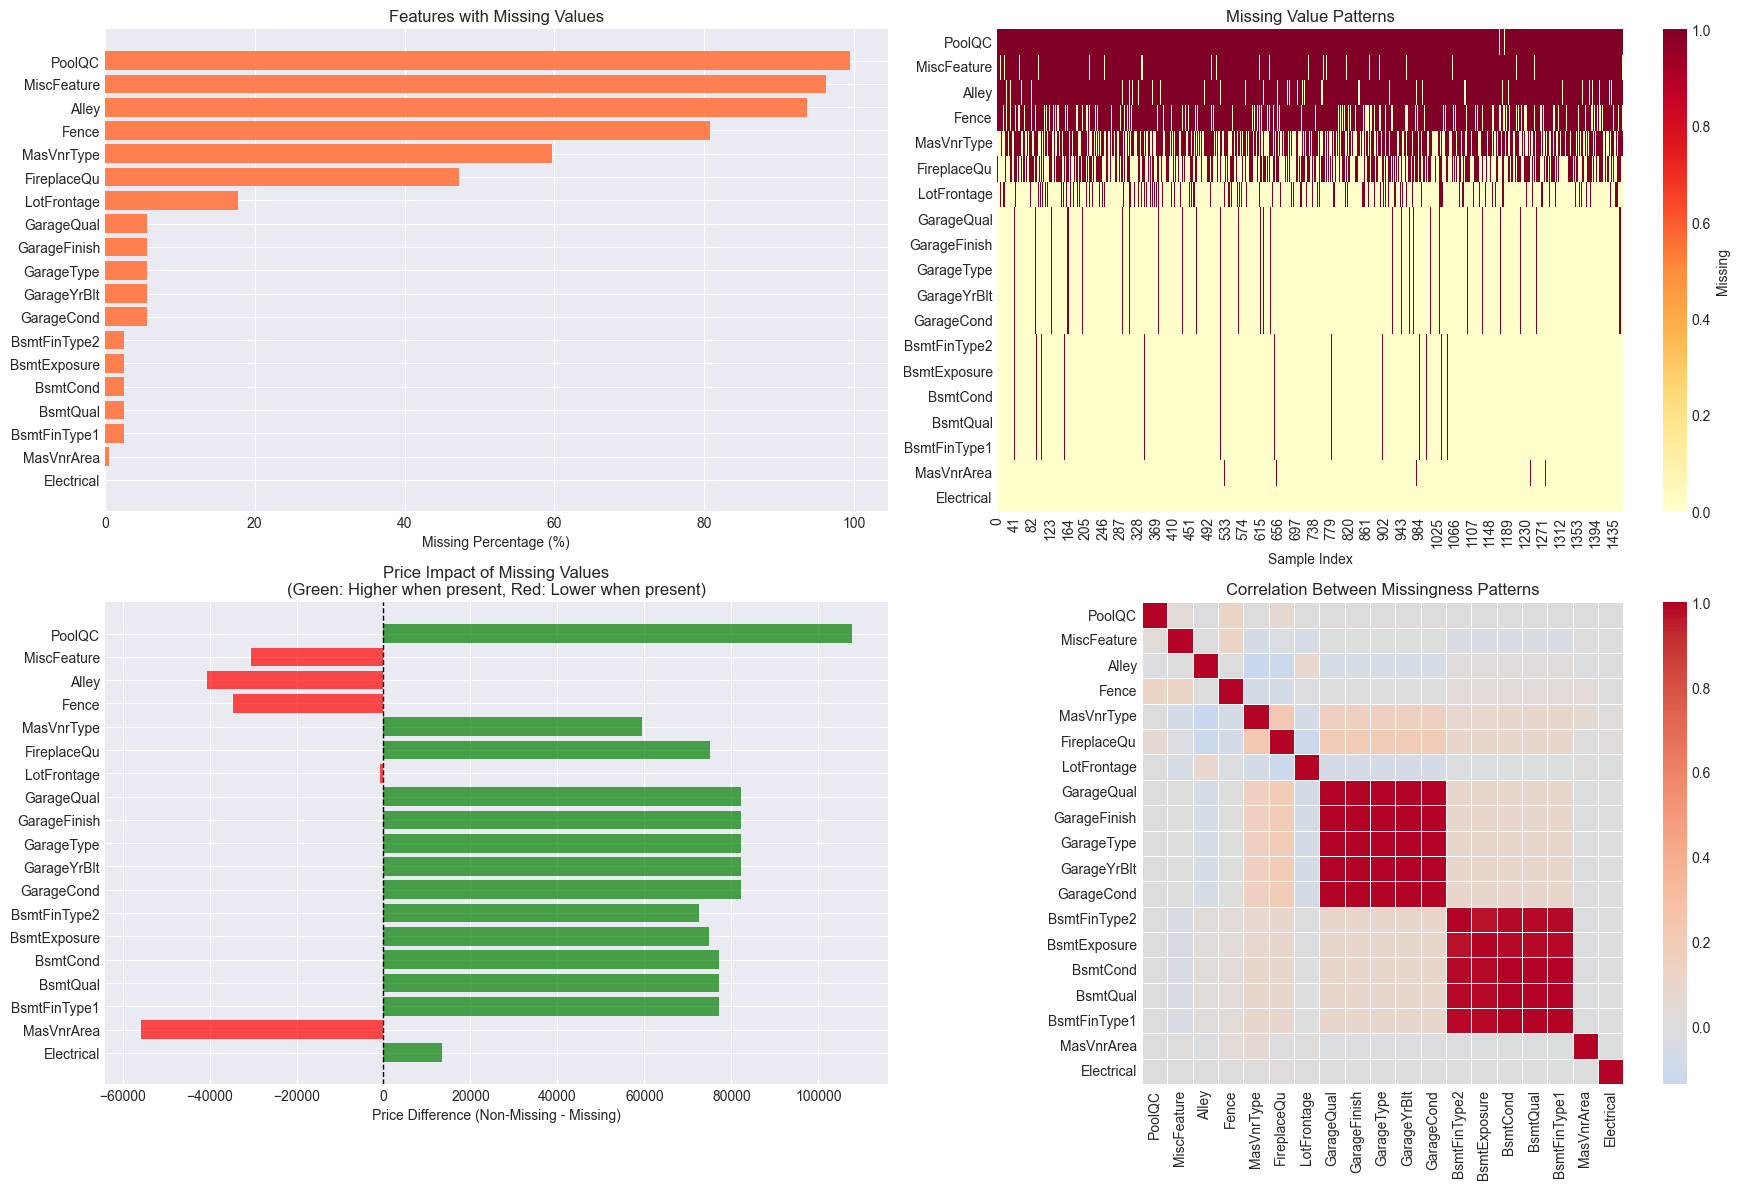

✓ Missing value visualizations complete


In [60]:
# Visualize missing values
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Bar chart of missing percentages
ax1 = axes[0, 0]
ax1.barh(range(len(missing_with_values)), missing_with_values['Missing_Percentage'], color='coral')
ax1.set_yticks(range(len(missing_with_values)))
ax1.set_yticklabels(missing_with_values['Feature'])
ax1.set_xlabel('Missing Percentage (%)')
ax1.set_title('Features with Missing Values')
ax1.invert_yaxis()

# 2. Heatmap of missing value patterns
ax2 = axes[0, 1]
missing_cols = missing_with_values['Feature'].tolist()
missing_matrix = train_df[missing_cols].isnull().astype(int)
sns.heatmap(missing_matrix.T, cmap='YlOrRd', cbar_kws={'label': 'Missing'}, ax=ax2, yticklabels=missing_cols)
ax2.set_title('Missing Value Patterns')
ax2.set_xlabel('Sample Index')

# 3. Price impact of missingness
ax3 = axes[1, 0]
price_impact = missing_with_values.dropna(subset=['Price_Difference'])
colors = ['green' if x > 0 else 'red' for x in price_impact['Price_Difference']]
ax3.barh(range(len(price_impact)), price_impact['Price_Difference'], color=colors, alpha=0.7)
ax3.set_yticks(range(len(price_impact)))
ax3.set_yticklabels(price_impact['Feature'])
ax3.set_xlabel('Price Difference (Non-Missing - Missing)')
ax3.set_title('Price Impact of Missing Values\n(Green: Higher when present, Red: Lower when present)')
ax3.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax3.invert_yaxis()

# 4. Missing value correlation matrix
ax4 = axes[1, 1]
missing_indicators = train_df[missing_cols].isnull().astype(int)
missing_corr = missing_indicators.corr()
sns.heatmap(missing_corr, annot=False, cmap='coolwarm', center=0, ax=ax4, 
            square=True, linewidths=0.5)
ax4.set_title('Correlation Between Missingness Patterns')

plt.tight_layout()
plt.show()

print("✓ Missing value visualizations complete")

JOINT MISSING VALUE PROBABILITY MATRIX
P(Feature_Column is missing | Feature_Row is missing)
              PoolQC  MiscFeature  Alley  Fence  MasVnrType  FireplaceQu  \
PoolQC          1.00         0.96   0.94   0.81        0.60         0.47   
MiscFeature     1.00         1.00   0.94   0.82        0.59         0.47   
Alley           0.99         0.96   1.00   0.81        0.58         0.46   
Fence           1.00         0.97   0.94   1.00        0.58         0.46   
MasVnrType      1.00         0.95   0.91   0.78        1.00         0.57   
FireplaceQu     1.00         0.96   0.91   0.78        0.72         1.00   
LotFrontage     1.00         0.94   0.98   0.80        0.53         0.35   
GarageQual      1.00         0.96   0.89   0.80        0.93         0.89   
GarageFinish    1.00         0.96   0.89   0.80        0.93         0.89   
GarageType      1.00         0.96   0.89   0.80        0.93         0.89   
GarageYrBlt     1.00         0.96   0.89   0.80        0.93         0.8

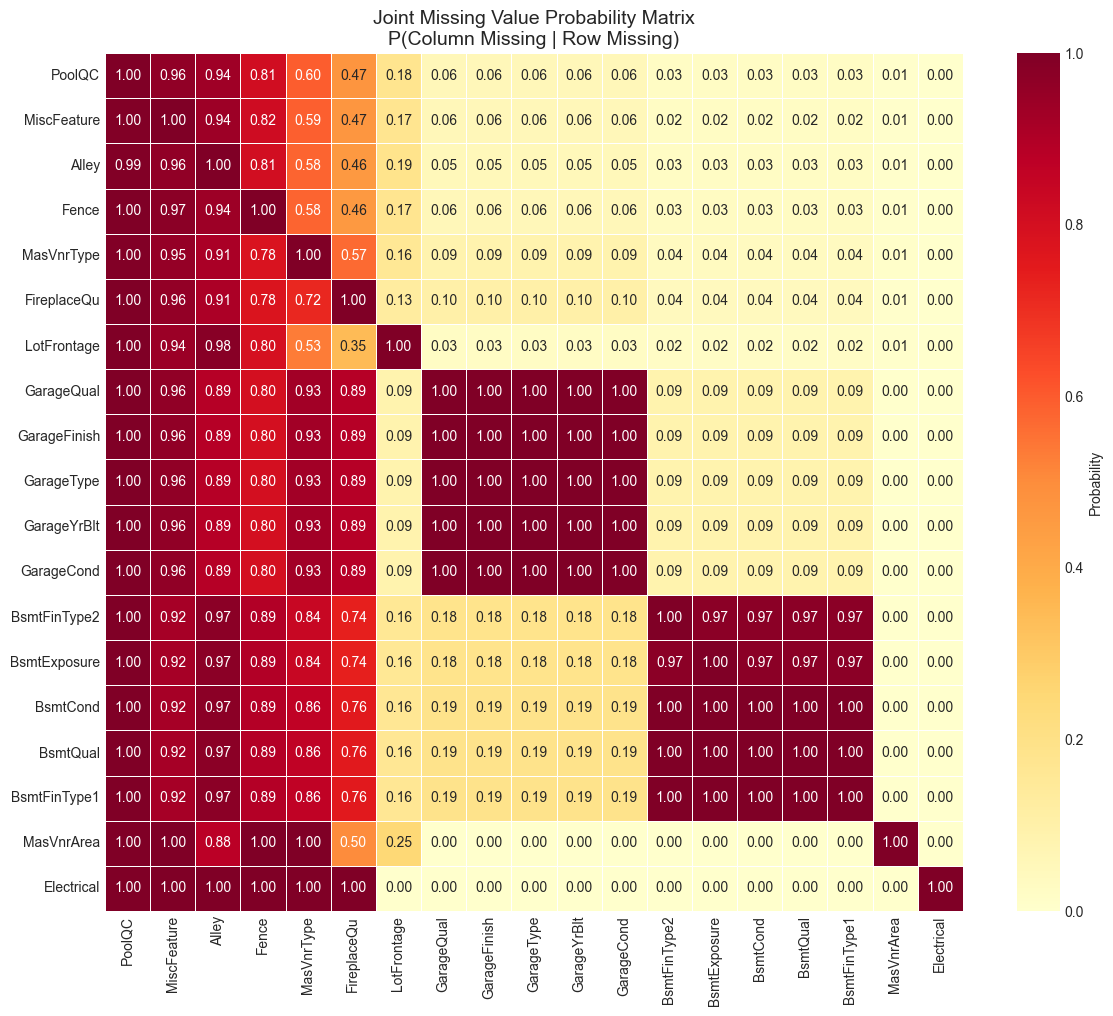

In [61]:
# Joint missing value probability - identify features that tend to be missing together
missing_cols_subset = missing_with_values['Feature'].tolist()
joint_missing_prob = pd.DataFrame(index=missing_cols_subset, columns=missing_cols_subset)

for col1 in missing_cols_subset:
    for col2 in missing_cols_subset:
        # Probability that col2 is missing given col1 is missing
        if train_df[col1].isnull().sum() > 0:
            prob = (train_df[col1].isnull() & train_df[col2].isnull()).sum() / train_df[col1].isnull().sum()
            joint_missing_prob.loc[col1, col2] = prob
        else:
            joint_missing_prob.loc[col1, col2] = 0

joint_missing_prob = joint_missing_prob.astype(float)

print("="*80)
print("JOINT MISSING VALUE PROBABILITY MATRIX")
print("P(Feature_Column is missing | Feature_Row is missing)")
print("="*80)
print(joint_missing_prob.round(2))

# Visualize
plt.figure(figsize=(12, 10))
sns.heatmap(joint_missing_prob, annot=True, fmt='.2f', cmap='YlOrRd', 
            square=True, linewidths=0.5, cbar_kws={'label': 'Probability'})
plt.title('Joint Missing Value Probability Matrix\nP(Column Missing | Row Missing)', fontsize=14)
plt.tight_layout()
plt.show()

<a id="section4"></a>
## 4. Target Variable Analysis

Comprehensive analysis of the SalePrice distribution, skewness, outliers, and relationships.

SALE PRICE STATISTICS
Mean: $180,921.20
Median: $163,000.00
Std Dev: $79,442.50
Min: $34,900.00
Max: $755,000.00
Skewness: 1.8829
Kurtosis: 6.5363


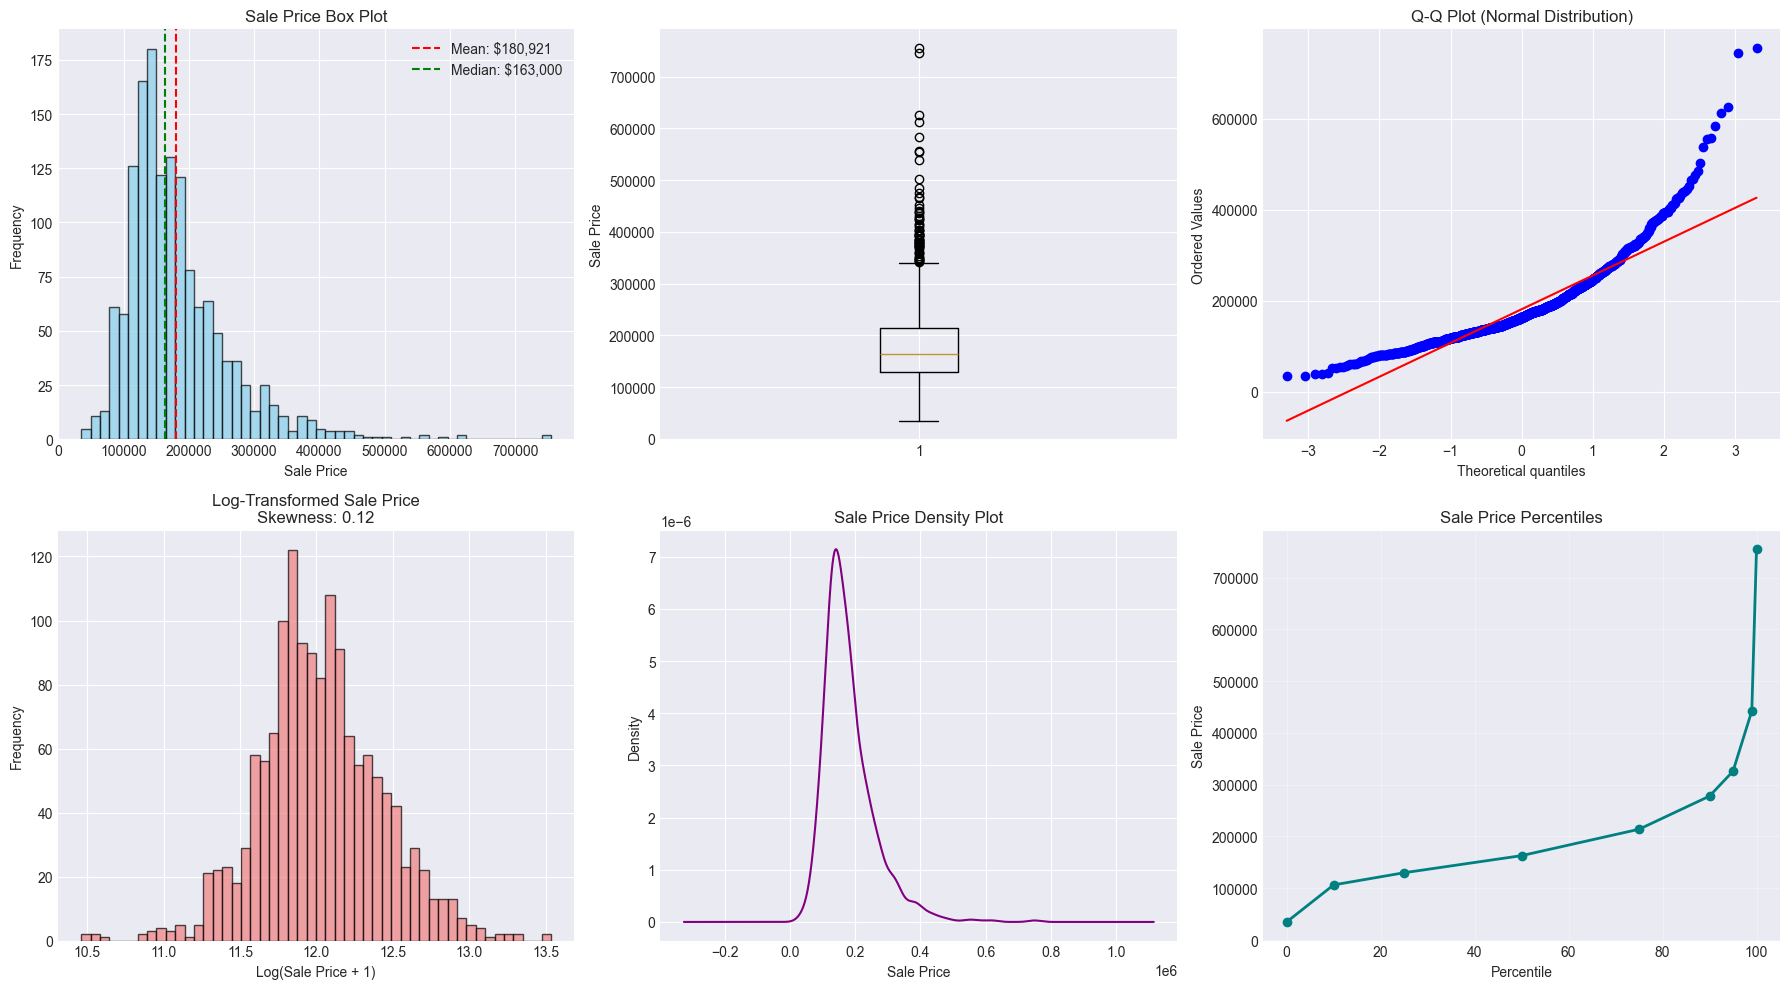


✓ Target variable analysis complete

Recommendation: Apply log transformation


In [62]:
# Analyze SalePrice (target variable)
sale_price = train_df['SalePrice']

print("="*80)
print("SALE PRICE STATISTICS")
print("="*80)
print(f"Mean: ${sale_price.mean():,.2f}")
print(f"Median: ${sale_price.median():,.2f}")
print(f"Std Dev: ${sale_price.std():,.2f}")
print(f"Min: ${sale_price.min():,.2f}")
print(f"Max: ${sale_price.max():,.2f}")
print(f"Skewness: {sale_price.skew():.4f}")
print(f"Kurtosis: {sale_price.kurtosis():.4f}")

# Visualize Sale Price distribution
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Histogram
ax1 = axes[0, 0]
ax1.hist(sale_price, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
ax1.axvline(sale_price.mean(), color='red', linestyle='--', label=f'Mean: ${sale_price.mean():,.0f}')
ax1.axvline(sale_price.median(), color='green', linestyle='--', label=f'Median: ${sale_price.median():,.0f}')
ax1.set_xlabel('Sale Price')
ax1.set_ylabel('Frequency')
ax1.set_title(f'Sale Price Distribution\nSkewness: {sale_price.skew():.2f}')
ax1.legend()

# 2. Box plot
ax2 = axes[0, 1]
ax2.boxplot(sale_price, vert=True)
ax2.set_ylabel('Sale Price')
ax1.set_title('Sale Price Box Plot')

# 3. Q-Q plot
ax3 = axes[0, 2]
stats.probplot(sale_price, dist="norm", plot=ax3)
ax3.set_title('Q-Q Plot (Normal Distribution)')

# 4. Log-transformed histogram
ax4 = axes[1, 0]
log_price = np.log1p(sale_price)
ax4.hist(log_price, bins=50, edgecolor='black', alpha=0.7, color='lightcoral')
ax4.set_xlabel('Log(Sale Price + 1)')
ax4.set_ylabel('Frequency')
ax4.set_title(f'Log-Transformed Sale Price\nSkewness: {log_price.skew():.2f}')

# 5. Density plot
ax5 = axes[1, 1]
sale_price.plot(kind='density', ax=ax5, color='purple')
ax5.set_xlabel('Sale Price')
ax5.set_title('Sale Price Density Plot')

# 6. Percentiles
ax6 = axes[1, 2]
percentiles = [0, 10, 25, 50, 75, 90, 95, 99, 100]
percentile_values = [np.percentile(sale_price, p) for p in percentiles]
ax6.plot(percentiles, percentile_values, marker='o', color='teal', linewidth=2)
ax6.set_xlabel('Percentile')
ax6.set_ylabel('Sale Price')
ax6.set_title('Sale Price Percentiles')
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Target variable analysis complete")
print(f"\nRecommendation: {'Apply log transformation' if sale_price.skew() > 0.5 else 'No transformation needed'}")

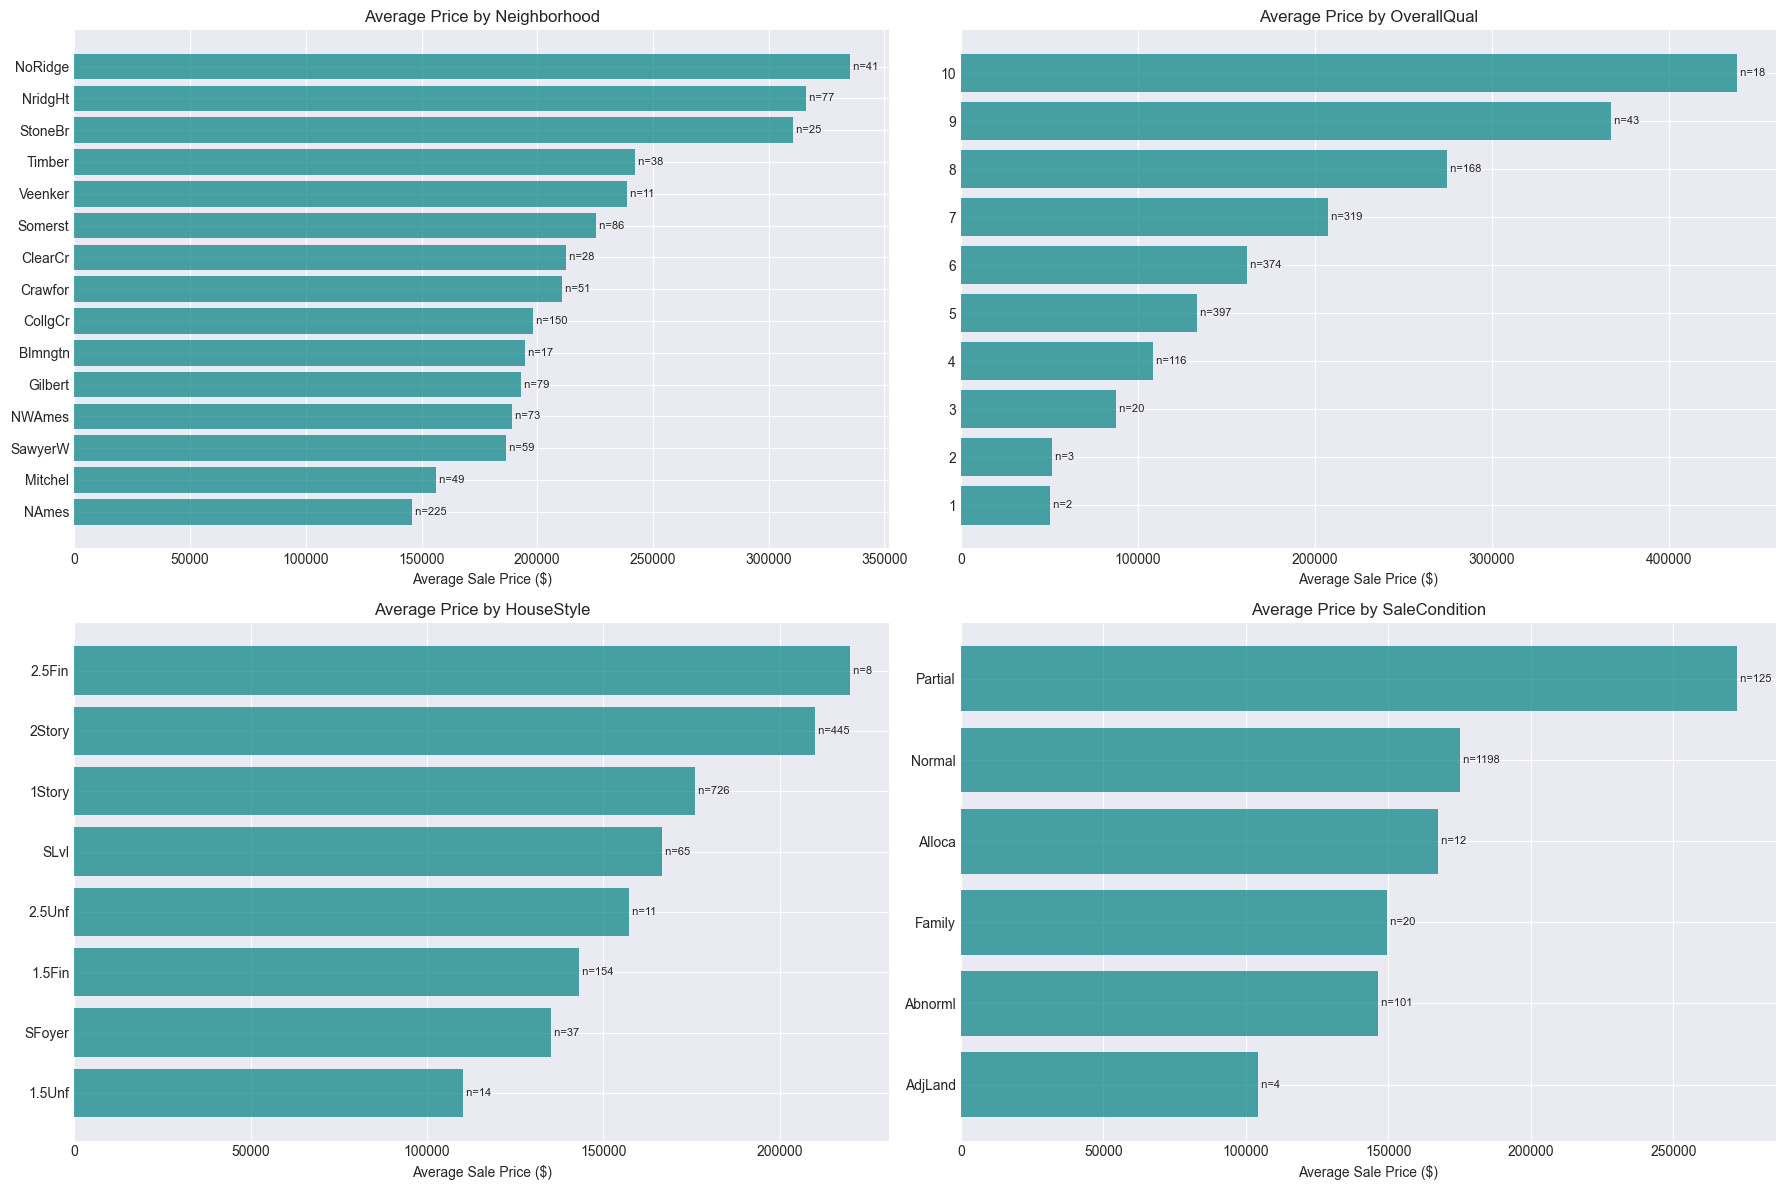

✓ Price distribution by categorical features visualized


In [63]:
# Price distribution by key categorical features
key_categoricals = ['Neighborhood', 'OverallQual', 'HouseStyle', 'SaleCondition']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, cat in enumerate(key_categoricals):
    if cat in train_df.columns:
        # Group by category and calculate mean price
        price_by_cat = train_df.groupby(cat)['SalePrice'].agg(['mean', 'count']).sort_values('mean', ascending=False)
        
        # Plot top categories
        top_cats = price_by_cat.head(15)
        axes[idx].barh(range(len(top_cats)), top_cats['mean'], color='teal', alpha=0.7)
        axes[idx].set_yticks(range(len(top_cats)))
        axes[idx].set_yticklabels(top_cats.index)
        axes[idx].set_xlabel('Average Sale Price ($)')
        axes[idx].set_title(f'Average Price by {cat}')
        axes[idx].invert_yaxis()
        
        # Add count labels
        for i, (idx_val, row) in enumerate(top_cats.iterrows()):
            axes[idx].text(row['mean'], i, f" n={int(row['count'])}", va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("✓ Price distribution by categorical features visualized")

<a id="section5"></a>
## 5. Feature Relationships and Correlation

Analyze correlations, multicollinearity, and feature-target relationships.

TOP 20 FEATURES CORRELATED WITH SALEPRICE
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
WoodDeckSF      0.324413
2ndFlrSF        0.319334
OpenPorchSF     0.315856
HalfBath        0.284108
LotArea         0.263843
Name: SalePrice, dtype: float64


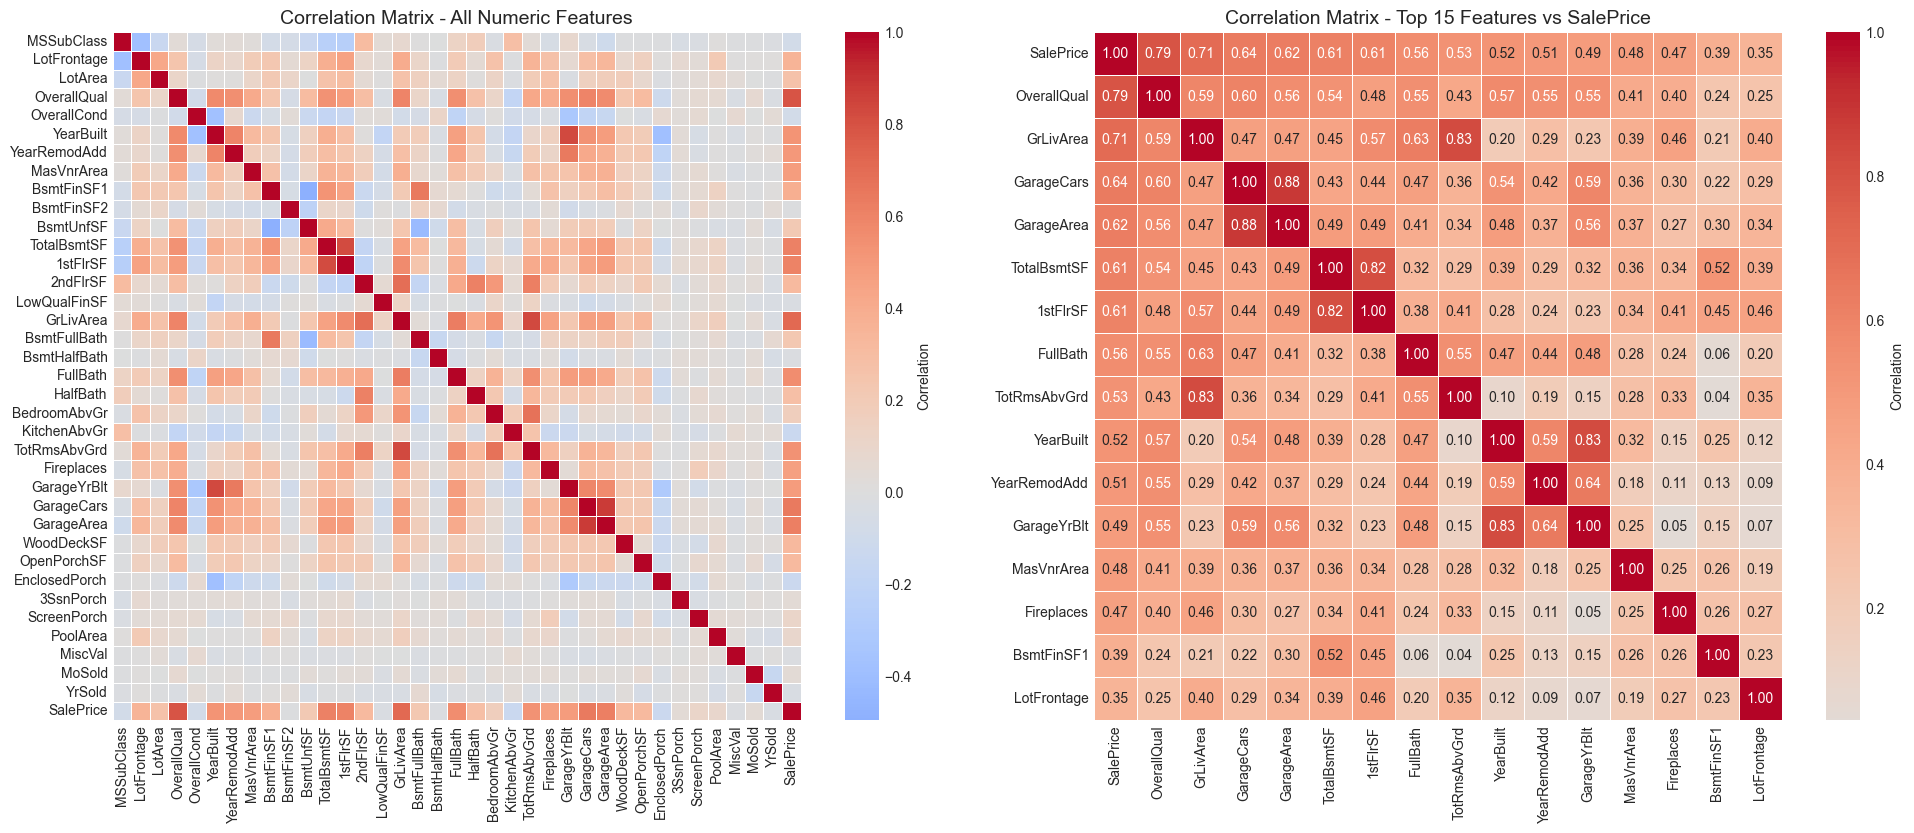


✓ Correlation analysis complete


In [64]:
# Correlation matrix for numeric features
numeric_train = train_df[numeric_features + ['SalePrice']].copy()

# Calculate correlation matrix
corr_matrix = numeric_train.corr()

# Find top correlations with SalePrice
price_corr = corr_matrix['SalePrice'].sort_values(ascending=False)
print("="*80)
print("TOP 20 FEATURES CORRELATED WITH SALEPRICE")
print("="*80)
print(price_corr.head(21))  # Top 20 + SalePrice itself

# Visualize correlation matrix
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Full correlation matrix
ax1 = axes[0]
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, ax=ax1, square=True, linewidths=0.5, 
            cbar_kws={'label': 'Correlation'}, annot=False)
ax1.set_title('Correlation Matrix - All Numeric Features', fontsize=14)

# Top features correlation with SalePrice
ax2 = axes[1]
top_features = price_corr.head(16).index.tolist()  # Top 15 + SalePrice
top_corr = numeric_train[top_features].corr()
sns.heatmap(top_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax2, 
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
ax2.set_title('Correlation Matrix - Top 15 Features vs SalePrice', fontsize=14)

plt.tight_layout()
plt.show()

print("\n✓ Correlation analysis complete")

VARIANCE INFLATION FACTOR (VIF) - Multicollinearity Check
VIF > 10: High multicollinearity
VIF 5-10: Moderate multicollinearity
VIF < 5: Low multicollinearity

          Feature           VIF
10   GarageYrBlt  22612.439111
8      YearBuilt  16872.532343
9   YearRemodAdd  12287.770056
7   TotRmsAbvGrd     61.798881
0    OverallQual     55.417761
1      GrLivArea     50.736187
5       1stFlrSF     41.918946
2     GarageCars     37.072591
3     GarageArea     33.754825
4    TotalBsmtSF     29.081304
6       FullBath     19.604636
14   LotFrontage     13.273067
13    BsmtFinSF1      2.915568
12    Fireplaces      2.779291
11    MasVnrArea      1.868985


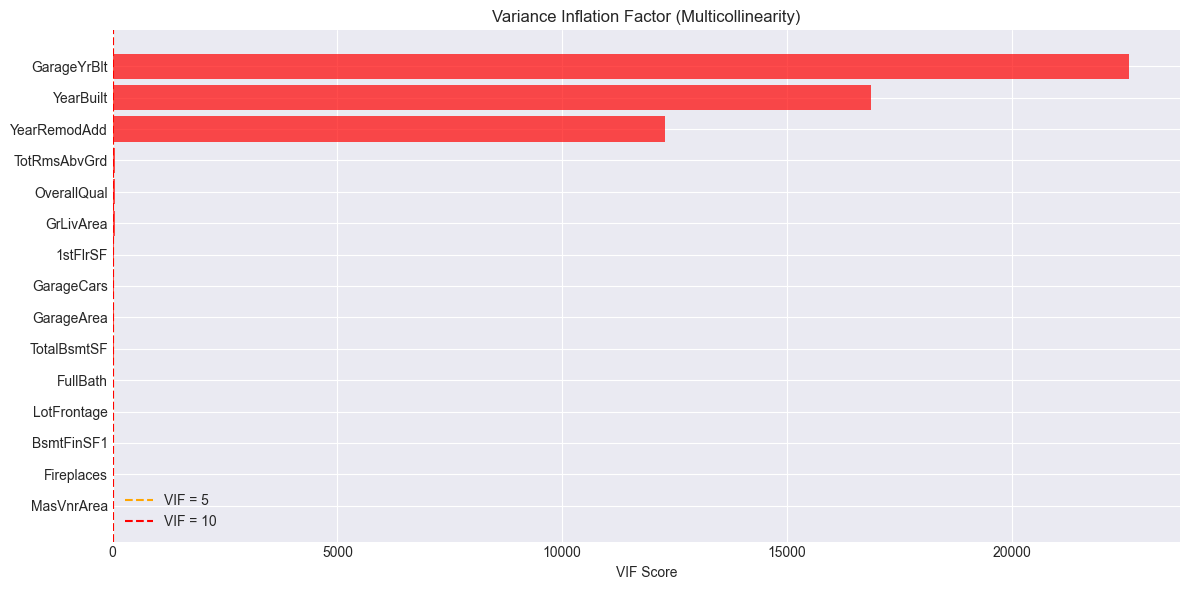


✓ Multicollinearity analysis complete


In [65]:
# Identify multicollinearity using VIF (Variance Inflation Factor)
# Select top correlated features for VIF analysis
top_numeric_features = price_corr.head(16).index.tolist()[1:]  # Exclude SalePrice

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = top_numeric_features
vif_data["VIF"] = [variance_inflation_factor(numeric_train[top_numeric_features].dropna().values, i) 
                   for i in range(len(top_numeric_features))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("="*80)
print("VARIANCE INFLATION FACTOR (VIF) - Multicollinearity Check")
print("="*80)
print("VIF > 10: High multicollinearity")
print("VIF 5-10: Moderate multicollinearity")
print("VIF < 5: Low multicollinearity")
print("\n", vif_data)

# Visualize VIF
plt.figure(figsize=(12, 6))
colors = ['red' if x > 10 else 'orange' if x > 5 else 'green' for x in vif_data['VIF']]
plt.barh(range(len(vif_data)), vif_data['VIF'], color=colors, alpha=0.7)
plt.yticks(range(len(vif_data)), vif_data['Feature'])
plt.xlabel('VIF Score')
plt.title('Variance Inflation Factor (Multicollinearity)')
plt.axvline(x=5, color='orange', linestyle='--', label='VIF = 5')
plt.axvline(x=10, color='red', linestyle='--', label='VIF = 10')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n✓ Multicollinearity analysis complete")

DOMAIN-DRIVEN FEATURE GROUPS

Property_Type (4 features):
  MSSubClass, MSZoning, BldgType, HouseStyle

Location (3 features):
  Neighborhood, Condition1, Condition2

Lot_Size_Shape (4 features):
  LotFrontage, LotArea, LotShape, LotConfig

Lot_Topography (2 features):
  LandContour, LandSlope

Access_Utilities (3 features):
  Street, Alley, Utilities

Exterior_Material (4 features):
  Exterior1st, Exterior2nd, MasVnrType, MasVnrArea

Exterior_Quality (2 features):
  ExterQual, ExterCond

Roof (2 features):
  RoofStyle, RoofMatl

Foundation (1 features):
  Foundation

Basement_Quality (3 features):
  BsmtQual, BsmtCond, BsmtExposure

Basement_Finish (6 features):
  BsmtFinType1, BsmtFinSF1, BsmtFinType2, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF

Basement_Bathrooms (2 features):
  BsmtFullBath, BsmtHalfBath

Floor_Area (4 features):
  1stFlrSF, 2ndFlrSF, LowQualFinSF, GrLivArea

Rooms (3 features):
  BedroomAbvGr, KitchenAbvGr, TotRmsAbvGrd

Bathrooms (2 features):
  FullBath, HalfBath

Kitch

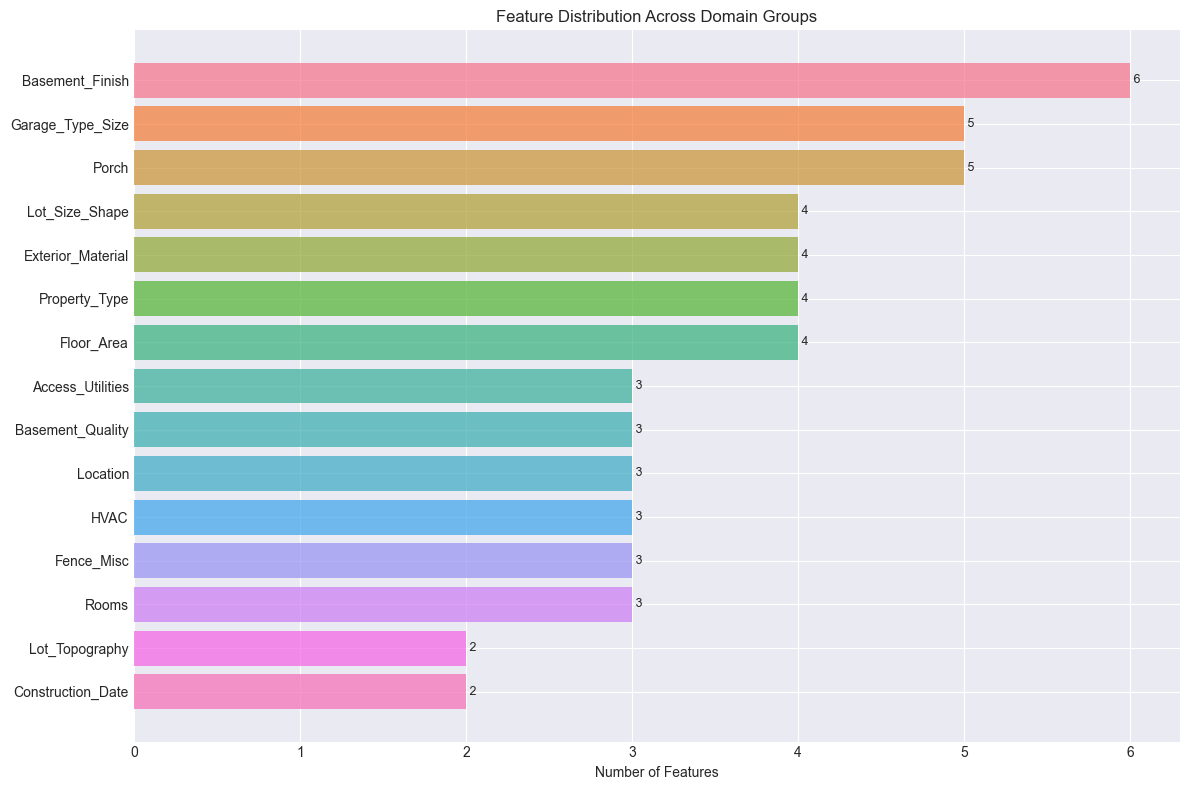


✓ Domain-driven feature grouping complete


In [66]:
# Comprehensive feature grouping based on data_description.txt
feature_groups = {
    # Property Identification & Location
    'Property_Type': ['MSSubClass', 'MSZoning', 'BldgType', 'HouseStyle'],
    'Location': ['Neighborhood', 'Condition1', 'Condition2'],
    
    # Lot Characteristics
    'Lot_Size_Shape': ['LotFrontage', 'LotArea', 'LotShape', 'LotConfig'],
    'Lot_Topography': ['LandContour', 'LandSlope'],
    'Access_Utilities': ['Street', 'Alley', 'Utilities'],
    
    # Exterior Features
    'Exterior_Material': ['Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea'],
    'Exterior_Quality': ['ExterQual', 'ExterCond'],
    'Roof': ['RoofStyle', 'RoofMatl'],
    
    # Foundation & Basement
    'Foundation': ['Foundation'],
    'Basement_Quality': ['BsmtQual', 'BsmtCond', 'BsmtExposure'],
    'Basement_Finish': ['BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF'],
    'Basement_Bathrooms': ['BsmtFullBath', 'BsmtHalfBath'],
    
    # Living Area
    'Floor_Area': ['1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea'],
    'Rooms': ['BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd'],
    'Bathrooms': ['FullBath', 'HalfBath'],
    
    # Kitchen & Quality
    'Kitchen': ['KitchenAbvGr', 'KitchenQual'],
    'Overall_Quality': ['OverallQual', 'OverallCond'],
    'Functional': ['Functional'],
    
    # Heating & Cooling
    'HVAC': ['Heating', 'HeatingQC', 'CentralAir'],
    'Electrical': ['Electrical'],
    
    # Garage
    'Garage_Type_Size': ['GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea'],
    'Garage_Quality': ['GarageQual', 'GarageCond'],
    
    # Outdoor Amenities
    'Porch': ['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch'],
    'Pool': ['PoolArea', 'PoolQC'],
    'Fireplace': ['Fireplaces', 'FireplaceQu'],
    'Fence_Misc': ['Fence', 'MiscFeature', 'MiscVal'],
    'Driveway': ['PavedDrive'],
    
    # Temporal Features
    'Construction_Date': ['YearBuilt', 'YearRemodAdd'],
    'Sale_Date': ['MoSold', 'YrSold'],
    
    # Sale Information
    'Sale_Details': ['SaleType', 'SaleCondition']
}

print("="*80)
print("DOMAIN-DRIVEN FEATURE GROUPS")
print("="*80)

# Display groups with their features
for group_name, features in feature_groups.items():
    # Filter to only existing features
    existing_features = [f for f in features if f in train_df.columns]
    if existing_features:
        print(f"\n{group_name} ({len(existing_features)} features):")
        print(f"  {', '.join(existing_features)}")

# Create summary
group_summary = pd.DataFrame({
    'Group': [k for k, v in feature_groups.items()],
    'Count': [len([f for f in v if f in train_df.columns]) for k, v in feature_groups.items()],
    'Features': [', '.join([f for f in v if f in train_df.columns][:3]) + '...' if len([f for f in v if f in train_df.columns]) > 3 else ', '.join([f for f in v if f in train_df.columns]) for k, v in feature_groups.items()]
}).sort_values('Count', ascending=False)

# Remove groups with 0 features
group_summary = group_summary[group_summary['Count'] > 0]

print("\n" + "="*80)
print("FEATURE GROUP SUMMARY")
print("="*80)
print(group_summary.to_string(index=False))
print(f"\nTotal feature groups: {len(group_summary)}")
print(f"Total features categorized: {group_summary['Count'].sum()}")
print(f"Total features in dataset: {len(train_df.columns) - 2}")  # Exclude Id and SalePrice

# Visualize feature distribution across groups
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 8))
top_groups = group_summary.head(15)
colors = sns.color_palette("husl", len(top_groups))
ax.barh(range(len(top_groups)), top_groups['Count'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_groups)))
ax.set_yticklabels(top_groups['Group'])
ax.set_xlabel('Number of Features')
ax.set_title('Feature Distribution Across Domain Groups')
ax.invert_yaxis()

# Add count labels
for i, (idx, row) in enumerate(top_groups.iterrows()):
    ax.text(row['Count'], i, f" {int(row['Count'])}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Domain-driven feature grouping complete")

<a id="section6"></a>
## 6. Missing Value Treatment Strategy

Systematic approach to handle missing values based on domain knowledge and patterns.

In [67]:
# Create copies for preprocessing
train_processed = train_df.copy()
test_processed = test_df.copy()

# Strategy 1: Features where NA means "None" (absence of feature)
# Based on data_description.txt
na_means_none = {
    # === CATEGORICAL FEATURES WHERE NA = "None" (No Feature Present) ===
    
    # Alley: NA = No alley access
    'Alley': 'No_Alley',
    
    # Basement Features: NA = No Basement
    'BsmtQual': 'No_Basement',      # Basement quality
    'BsmtCond': 'No_Basement',      # Basement condition
    'BsmtExposure': 'No_Basement',  # Basement exposure (walkout/garden level)
    'BsmtFinType1': 'No_Basement',  # Basement finished area type 1
    'BsmtFinType2': 'No_Basement',  # Basement finished area type 2
    
    # Fireplace: NA = No Fireplace
    'FireplaceQu': 'No_Fireplace',  # Fireplace quality
    
    # Garage Features: NA = No Garage
    'GarageType': 'No_Garage',      # Garage location/type
    'GarageFinish': 'No_Garage',    # Garage interior finish
    'GarageQual': 'No_Garage',      # Garage quality
    'GarageCond': 'No_Garage',      # Garage condition
    
    # Pool: NA = No Pool
    'PoolQC': 'No_Pool',            # Pool quality
    
    # Fence: NA = No Fence
    'Fence': 'No_Fence',            # Fence quality
    
    # Miscellaneous Feature: NA = None
    'MiscFeature': 'None',          # Miscellaneous feature (elevator, 2nd garage, etc.)
    
    # Masonry Veneer: NA = None
    'MasVnrType': 'None',           # Masonry veneer type
    
    # === NUMERIC FEATURES WHERE NA = 0 (Truly Zero, Not Missing) ===
    
    # Basement Square Footage: NA = 0 (no basement)
    'BsmtFinSF1': 0,        # Type 1 finished square feet
    'BsmtFinSF2': 0,        # Type 2 finished square feet
    'BsmtUnfSF': 0,         # Unfinished square feet
    'TotalBsmtSF': 0,       # Total basement square feet
    
    # Basement Bathrooms: NA = 0 (no basement)
    'BsmtFullBath': 0,      # Basement full bathrooms
    'BsmtHalfBath': 0,      # Basement half bathrooms
    
    # Garage: NA = 0 (no garage)
    'GarageArea': 0,        # Garage area in square feet
    'GarageCars': 0,        # Garage capacity in cars
    
    # Masonry Veneer: NA = 0 (no masonry veneer)
    'MasVnrArea': 0,        # Masonry veneer area in square feet
    
    # Lot Frontage: NA = 0 or will be imputed (linear feet of street)
    'LotFrontage': 0,       # Could also use neighborhood median
}

# Apply NA = None/0 strategy
for feature, fill_value in na_means_none.items():
    if feature in train_processed.columns:
        train_processed[feature].fillna(fill_value, inplace=True)
    if feature in test_processed.columns:
        test_processed[feature].fillna(fill_value, inplace=True)

# Special handling for GarageYrBlt (YEAR values, not zero)
for df in [train_processed, test_processed]:
    if 'GarageYrBlt' in df.columns and 'YearBuilt' in df.columns:
        # Intelligent imputation:
        # 1. If no garage → use YearBuilt (house built without garage)
        # 2. If has garage but year missing → use YearBuilt (assume built together)
        df['GarageYrBlt'].fillna(df['YearBuilt'], inplace=True)
        
        # Create useful derived features
        if 'YrSold' in df.columns:
            df['GarageAge'] = df['YrSold'] - df['GarageYrBlt']
            df['GarageAge'] = df['GarageAge'].clip(lower=0)
        
        # Flag if garage was added after house was built
        df['GarageAddedLater'] = (df['GarageYrBlt'] > df['YearBuilt']).astype(int)

print("✓ Filled missing values with intelligent imputation")
print("  - GarageYrBlt: Imputed with YearBuilt (logical assumption)")
print("  - Created GarageAge and GarageAddedLater features")

# Strategy 2: Impute with mode for low-cardinality categorical features with low missingness
low_missing_categorical = []
for col in categorical_features:
    if col in train_processed.columns:
        missing_pct = 100 * train_processed[col].isnull().sum() / len(train_processed)
        if 0 < missing_pct < 5 and train_processed[col].nunique() < 20:
            mode_value = train_processed[col].mode()[0] if len(train_processed[col].mode()) > 0 else 'Missing'
            train_processed[col].fillna(mode_value, inplace=True)
            if col in test_processed.columns:
                test_processed[col].fillna(mode_value, inplace=True)
            low_missing_categorical.append(col)

print(f"✓ Filled {len(low_missing_categorical)} categorical features with mode: {low_missing_categorical}")

# Strategy 3: Impute with median for numeric features with low missingness
low_missing_numeric = []
for col in numeric_features:
    if col in train_processed.columns:
        missing_pct = 100 * train_processed[col].isnull().sum() / len(train_processed)
        if 0 < missing_pct < 5:
            median_value = train_processed[col].median()
            train_processed[col].fillna(median_value, inplace=True)
            if col in test_processed.columns:
                test_processed[col].fillna(median_value, inplace=True)
            low_missing_numeric.append(col)

print(f"✓ Filled {len(low_missing_numeric)} numeric features with median: {low_missing_numeric}")

# Strategy 4: Create missingness indicators for features with >15% missing
high_missing_features = missing_with_values[missing_with_values['Missing_Percentage'] > 15]['Feature'].tolist()
for feature in high_missing_features:
    if feature in train_processed.columns and feature != 'SalePrice':
        # Create indicator
        train_processed[f'{feature}_Missing'] = train_df[feature].isnull().astype(int)
        if feature in test_processed.columns:
            test_processed[f'{feature}_Missing'] = test_df[feature].isnull().astype(int)

print(f"✓ Created {len(high_missing_features)} missingness indicator features")

# Final check
remaining_missing_train = train_processed.isnull().sum().sum()
remaining_missing_test = test_processed.isnull().sum().sum()

print(f"\n{'='*80}")
print(f"MISSING VALUES AFTER TREATMENT")
print(f"{'='*80}")
print(f"Train set: {remaining_missing_train} missing values remaining")
print(f"Test set: {remaining_missing_test} missing values remaining")

for col in test_processed.columns:
    print(f"{col}: {test_processed[col].isnull().sum()} missing")

# Fill remaining with appropriate values
for col in train_processed.columns:
    if train_processed[col].isnull().sum() > 0:
        if train_processed[col].dtype == 'object':
            train_processed[col].fillna('Unknown', inplace=True)
        else:
            train_processed[col].fillna(train_processed[col].median(), inplace=True)

for col in test_processed.columns:
    if test_processed[col].isnull().sum() > 0:
        if test_processed[col].dtype == 'object':
            test_processed[col].fillna('Unknown', inplace=True)
        else:
            test_processed[col].fillna(test_processed[col].median(), inplace=True)


✓ Filled missing values with intelligent imputation
  - GarageYrBlt: Imputed with YearBuilt (logical assumption)
  - Created GarageAge and GarageAddedLater features
✓ Filled 1 categorical features with mode: ['Electrical']
✓ Filled 0 numeric features with median: []
✓ Created 7 missingness indicator features

MISSING VALUES AFTER TREATMENT
Train set: 0 missing values remaining
Test set: 12 missing values remaining
Id: 0 missing
MSSubClass: 0 missing
MSZoning: 4 missing
LotFrontage: 0 missing
LotArea: 0 missing
Street: 0 missing
Alley: 0 missing
LotShape: 0 missing
LandContour: 0 missing
Utilities: 2 missing
LotConfig: 0 missing
LandSlope: 0 missing
Neighborhood: 0 missing
Condition1: 0 missing
Condition2: 0 missing
BldgType: 0 missing
HouseStyle: 0 missing
OverallQual: 0 missing
OverallCond: 0 missing
YearBuilt: 0 missing
YearRemodAdd: 0 missing
RoofStyle: 0 missing
RoofMatl: 0 missing
Exterior1st: 1 missing
Exterior2nd: 1 missing
MasVnrType: 0 missing
MasVnrArea: 0 missing
ExterQual: 

<a id="section7"></a>
## 7. Categorical Feature Encoding

Apply appropriate encoding strategies based on cardinality and feature types.

In [68]:
# Define ordinal features with their order (based on data_description.txt)
# All Quality (Qual) and Condition (Cond) features are encoded as discrete numerical values (0-5)
ordinal_features = {
    # Quality and Condition Features - Standard 0-5 scale (None/NA=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5)
    'ExterQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],              # Exterior quality (1-5)
    'ExterCond': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],              # Exterior condition (1-5)
    'BsmtQual': ['No_Basement', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],    # Basement quality (0-5, 0=No Basement)
    'BsmtCond': ['No_Basement', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],    # Basement condition (0-5, 0=No Basement)
    'HeatingQC': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],              # Heating quality & condition (1-5)
    'KitchenQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],            # Kitchen quality (1-5)
    'FireplaceQu': ['No_Fireplace', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],  # Fireplace quality (0-5, 0=No Fireplace)
    'GarageQual': ['No_Garage', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],     # Garage quality (0-5, 0=No Garage)
    'GarageCond': ['No_Garage', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],     # Garage condition (0-5, 0=No Garage)
    'PoolQC': ['No_Pool', 'Fa', 'TA', 'Gd', 'Ex'],            # Pool quality (0-4, 0=No Pool, no Po rating)
    
    # Other Ordinal Features (not Qual/Cond but still ordinal)
    'BsmtExposure': ['No_Basement', 'No', 'Mn', 'Av', 'Gd'],
    'BsmtFinType1': ['No_Basement', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'BsmtFinType2': ['No_Basement', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'GarageFinish': ['No_Garage', 'Unf', 'RFn', 'Fin'],
    'Fence': ['No_Fence', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'],
    'LotShape': ['IR3', 'IR2', 'IR1', 'Reg'],
    'LandSlope': ['Sev', 'Mod', 'Gtl'],
    'Functional': ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
    'PavedDrive': ['N', 'P', 'Y']
}

# Apply ordinal encoding
ordinal_mapping = {}
qual_cond_features = []  # Track quality/condition features

for feature, categories in ordinal_features.items():
    if feature in train_processed.columns:
        # Create mapping
        mapping = {cat: idx for idx, cat in enumerate(categories)}
        ordinal_mapping[feature] = mapping
        
        # Track Qual/Cond features
        if 'Qual' in feature or 'Cond' in feature or 'QC' in feature:
            qual_cond_features.append(feature)
        
        # Apply to train
        train_processed[feature] = train_processed[feature].map(mapping)
        train_processed[feature].fillna(-1, inplace=True)  # Fill any unmapped values
        
        # Apply to test
        if feature in test_processed.columns:
            test_processed[feature] = test_processed[feature].map(mapping)
            test_processed[feature].fillna(-1, inplace=True)

print(f"✓ Encoded {len(ordinal_features)} ordinal features")
print(f"✓ Quality/Condition features encoded as 0-5 scale: {len(qual_cond_features)}")
print(f"  {qual_cond_features}")

# Identify remaining categorical features for one-hot encoding
remaining_categorical = [col for col in train_processed.select_dtypes(include=['object']).columns 
                        if col not in ['Id', 'SalePrice']]

# Separate by cardinality
low_cardinality = [col for col in remaining_categorical if train_processed[col].nunique() < 10]
high_cardinality = [col for col in remaining_categorical if train_processed[col].nunique() >= 10]

print(f"\nLow cardinality categorical features ({len(low_cardinality)}): {low_cardinality}")
print(f"High cardinality categorical features ({len(high_cardinality)}): {high_cardinality}")

# One-hot encode low cardinality features
if low_cardinality:
    train_encoded = pd.get_dummies(train_processed, columns=low_cardinality, prefix=low_cardinality, drop_first=True)
    test_encoded = pd.get_dummies(test_processed, columns=low_cardinality, prefix=low_cardinality, drop_first=True)
    
    # Align columns
    train_cols = set(train_encoded.columns)
    test_cols = set(test_encoded.columns)
    
    # Add missing columns to test
    for col in train_cols - test_cols:
        if col != 'SalePrice':
            test_encoded[col] = 0
    
    # Remove extra columns from test
    for col in test_cols - train_cols:
        test_encoded.drop(col, axis=1, inplace=True)
    
    # Reorder test columns to match train
    test_encoded = test_encoded[train_encoded.columns.drop('SalePrice', errors='ignore')]
    
    train_processed = train_encoded
    test_processed = test_encoded
    
    print(f"✓ One-hot encoded {len(low_cardinality)} low-cardinality features")

# Label encode high cardinality features (will use for some models)
label_encoders = {}
for col in high_cardinality:
    if col in train_processed.columns:
        le = LabelEncoder()
        train_processed[col] = le.fit_transform(train_processed[col].astype(str))
        label_encoders[col] = le
        
        if col in test_processed.columns:
            # Handle unseen categories
            test_processed[col] = test_processed[col].astype(str).apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

print(f"✓ Label encoded {len(high_cardinality)} high-cardinality features")

print(f"\nProcessed train shape: {train_processed.shape}")
print(f"Processed test shape: {test_processed.shape}")

✓ Encoded 19 ordinal features
✓ Quality/Condition features encoded as 0-5 scale: 9
  ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'GarageQual', 'GarageCond', 'PoolQC']

Low cardinality categorical features (21): ['MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities', 'LotConfig', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType', 'MiscFeature', 'SaleType', 'SaleCondition']
High cardinality categorical features (3): ['Neighborhood', 'Exterior1st', 'Exterior2nd']
✓ One-hot encoded 21 low-cardinality features
✓ Label encoded 3 high-cardinality features

Processed train shape: (1460, 163)
Processed test shape: (1459, 162)


<a id="section8"></a>
## 8. Feature Engineering and Creation

Create meaningful engineered features to improve model performance.

In [69]:
# Engineer new features for both train and test
def engineer_features(df):
    """Create engineered features"""
    df_eng = df.copy()
    
    # 1. Total Square Footage
    if all(col in df_eng.columns for col in ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']):
        df_eng['TotalSF'] = df_eng['TotalBsmtSF'] + df_eng['1stFlrSF'] + df_eng['2ndFlrSF']
    
    # 2. Total Bathrooms
    if all(col in df_eng.columns for col in ['BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath']):
        df_eng['TotalBath'] = df_eng['BsmtFullBath'] + 0.5*df_eng['BsmtHalfBath'] + df_eng['FullBath'] + 0.5*df_eng['HalfBath']
    
    # 3. Total Porch SF
    porch_cols = ['OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch']
    if all(col in df_eng.columns for col in porch_cols):
        df_eng['TotalPorchSF'] = df_eng[porch_cols].sum(axis=1)
    
    # 4. House Age (at time of sale)
    if all(col in df_eng.columns for col in ['YrSold', 'YearBuilt']):
        df_eng['HouseAge'] = df_eng['YrSold'] - df_eng['YearBuilt']
        df_eng['HouseAge'] = df_eng['HouseAge'].clip(lower=0)  # Ensure non-negative
    
    # 5. Years Since Remodel
    if all(col in df_eng.columns for col in ['YrSold', 'YearRemodAdd']):
        df_eng['YearsSinceRemodel'] = df_eng['YrSold'] - df_eng['YearRemodAdd']
        df_eng['YearsSinceRemodel'] = df_eng['YearsSinceRemodel'].clip(lower=0)
    
    # 6. Remodeling Flag
    if all(col in df_eng.columns for col in ['YearRemodAdd', 'YearBuilt']):
        df_eng['WasRemodeled'] = (df_eng['YearRemodAdd'] > df_eng['YearBuilt']).astype(int)
    
    # 7. Is New House (built and sold same year)
    if all(col in df_eng.columns for col in ['YrSold', 'YearBuilt']):
        df_eng['IsNewHouse'] = (df_eng['YrSold'] == df_eng['YearBuilt']).astype(int)
    
    # 8. Has 2nd Floor
    if '2ndFlrSF' in df_eng.columns:
        df_eng['Has2ndFloor'] = (df_eng['2ndFlrSF'] > 0).astype(int)
    
    # 9. Has Garage
    if 'GarageArea' in df_eng.columns:
        df_eng['HasGarage'] = (df_eng['GarageArea'] > 0).astype(int)
    
    # 10. Has Basement
    if 'TotalBsmtSF' in df_eng.columns:
        df_eng['HasBasement'] = (df_eng['TotalBsmtSF'] > 0).astype(int)
    
    # 11. Has Fireplace
    if 'Fireplaces' in df_eng.columns:
        df_eng['HasFireplace'] = (df_eng['Fireplaces'] > 0).astype(int)
    
    # 12. Has Pool
    if 'PoolArea' in df_eng.columns:
        df_eng['HasPool'] = (df_eng['PoolArea'] > 0).astype(int)
    
    # # 13. Overall Quality × Total SF (interaction)
    # if all(col in df_eng.columns for col in ['OverallQual', 'TotalSF']):
    #     df_eng['QualityTimesSize'] = df_eng['OverallQual'] * df_eng['TotalSF']
    
    # # 14. Overall Quality × Overall Condition
    # if all(col in df_eng.columns for col in ['OverallQual', 'OverallCond']):
    #     df_eng['QualityTimesCondition'] = df_eng['OverallQual'] * df_eng['OverallCond']
    
    # 15. Living Area Per Room
    if all(col in df_eng.columns for col in ['GrLivArea', 'TotRmsAbvGrd']):
        df_eng['AreaPerRoom'] = df_eng['GrLivArea'] / (df_eng['TotRmsAbvGrd'] + 1)  # +1 to avoid division by zero
    
    # 16. Lot Frontage to Area Ratio
    if all(col in df_eng.columns for col in ['LotFrontage', 'LotArea']):
        df_eng['FrontageRatio'] = df_eng['LotFrontage'] / (df_eng['LotArea'] + 1)
    
    # 17. Basement Finish Ratio
    if all(col in df_eng.columns for col in ['BsmtFinSF1', 'TotalBsmtSF']):
        df_eng['BsmtFinishRatio'] = df_eng['BsmtFinSF1'] / (df_eng['TotalBsmtSF'] + 1)
    
    # 18. Garage to House Area Ratio
    if all(col in df_eng.columns for col in ['GarageArea', 'GrLivArea']):
        df_eng['GarageRatio'] = df_eng['GarageArea'] / (df_eng['GrLivArea'] + 1)
    
    return df_eng

# Apply feature engineering
train_engineered = engineer_features(train_processed)
test_engineered = engineer_features(test_processed)

# Count new features
original_features = train_processed.shape[1]
new_features = train_engineered.shape[1]
added_features = new_features - original_features

print("="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)
print(f"Original features: {original_features}")
print(f"Engineered features added: {added_features}")
print(f"Total features: {new_features}")

print("\nNew Features Created:")
new_cols = [col for col in train_engineered.columns if col not in train_processed.columns]
for col in new_cols:
    print(f"  - {col}")

# Check correlation of new features with SalePrice
if 'SalePrice' in train_engineered.columns:
    new_feature_corr = train_engineered[new_cols + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)[1:]
    print(f"\n{'='*80}")
    print("CORRELATION OF NEW FEATURES WITH SALEPRICE")
    print("="*80)
    print(new_feature_corr)

print("\n✓ Feature engineering complete")

FEATURE ENGINEERING SUMMARY
Original features: 163
Engineered features added: 16
Total features: 179

New Features Created:
  - TotalSF
  - TotalBath
  - TotalPorchSF
  - HouseAge
  - YearsSinceRemodel
  - WasRemodeled
  - IsNewHouse
  - Has2ndFloor
  - HasGarage
  - HasBasement
  - HasFireplace
  - HasPool
  - AreaPerRoom
  - FrontageRatio
  - BsmtFinishRatio
  - GarageRatio

CORRELATION OF NEW FEATURES WITH SALEPRICE
TotalSF              0.782260
TotalBath            0.631731
AreaPerRoom          0.616235
HasFireplace         0.471908
HasGarage            0.236832
IsNewHouse           0.224807
TotalPorchSF         0.195739
BsmtFinishRatio      0.163914
HasBasement          0.152829
Has2ndFloor          0.137656
HasPool              0.093708
GarageRatio          0.089932
WasRemodeled        -0.021933
FrontageRatio       -0.130517
YearsSinceRemodel   -0.509096
HouseAge            -0.523350
Name: SalePrice, dtype: float64

✓ Feature engineering complete


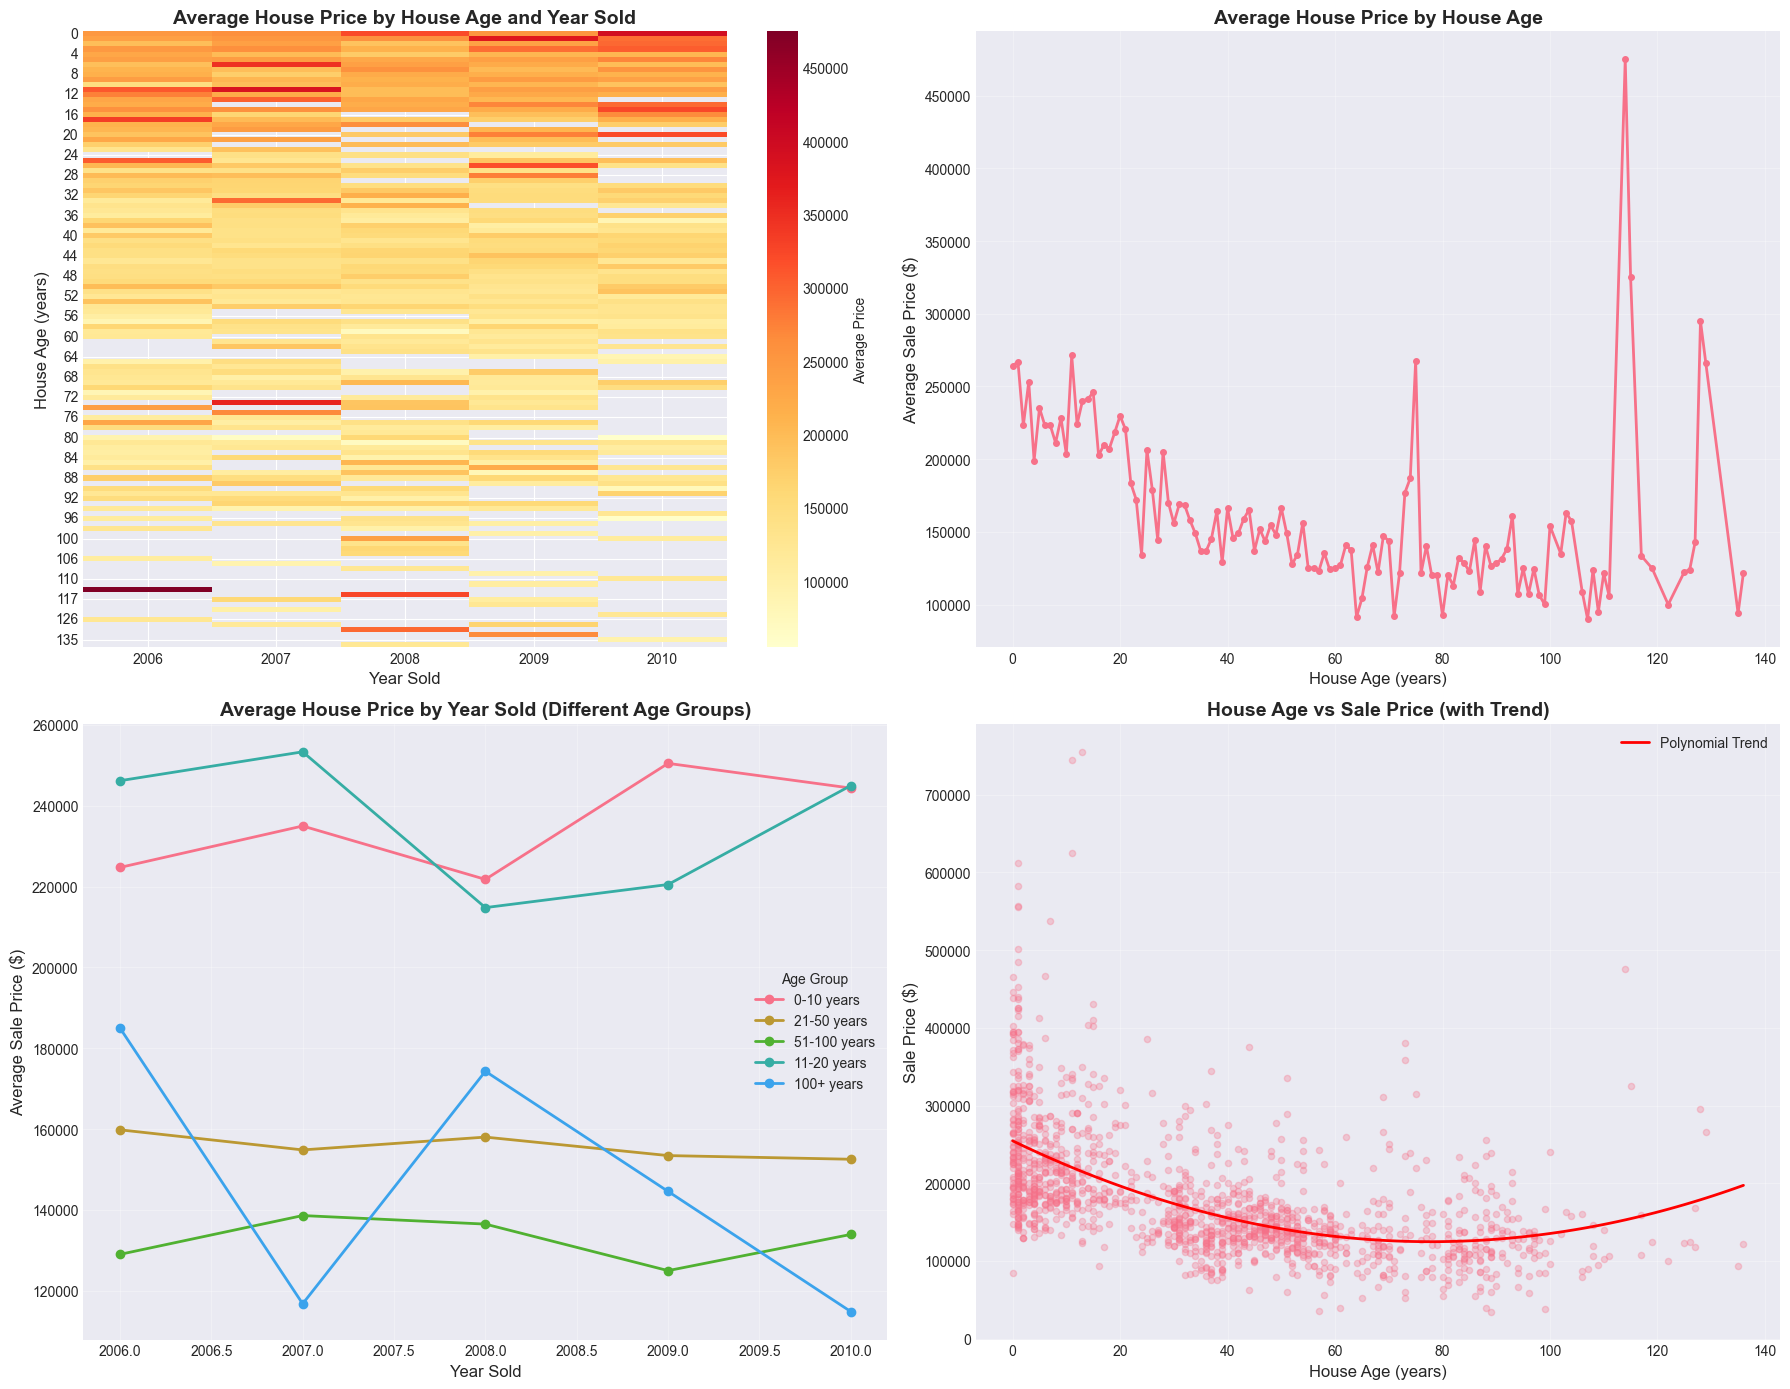


=== Summary Statistics ===

House Age Range: 0 - 136 years
Average House Age: 36.5 years
Median House Age: 35.0 years

Average Price by Age Group:
              mean    median  count
AgeGroup                           
0-10      234567.0  214000.0    370
11-20     234833.0  209450.0    130
21-50     155952.0  147000.0    457
51-100    132249.0  127000.0    411
100+      153118.0  123250.0     28


In [70]:
# Visualize average house price by House Age and Year Sold

# Calculate House Age (assuming YrSold exists in the data)
train_df['HouseAge'] = train_df['YrSold'] - train_df['YearBuilt']

# Create aggregated data for visualization
price_by_age_year = train_df.groupby(['HouseAge', 'YrSold'])['SalePrice'].mean().reset_index()

# Create a pivot table for heatmap
pivot_data = price_by_age_year.pivot(index='HouseAge', columns='YrSold', values='SalePrice')

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Heatmap: Average Price by House Age and Year Sold
sns.heatmap(pivot_data, cmap='YlOrRd', annot=False, fmt='.0f', ax=axes[0, 0], cbar_kws={'label': 'Average Price'})
axes[0, 0].set_title('Average House Price by House Age and Year Sold', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Year Sold', fontsize=12)
axes[0, 0].set_ylabel('House Age (years)', fontsize=12)

# 2. Line plot: Average Price by House Age (aggregated across all years)
avg_by_age = train_df.groupby('HouseAge')['SalePrice'].mean().reset_index()
axes[0, 1].plot(avg_by_age['HouseAge'], avg_by_age['SalePrice'], marker='o', linewidth=2, markersize=4)
axes[0, 1].set_title('Average House Price by House Age', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('House Age (years)', fontsize=12)
axes[0, 1].set_ylabel('Average Sale Price ($)', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# 3. Line plot: Average Price by Year Sold (for different age groups)
age_groups = pd.cut(train_df['HouseAge'], bins=[0, 10, 20, 50, 100, 200], labels=['0-10', '11-20', '21-50', '51-100', '100+'])
train_df['AgeGroup'] = age_groups

for age_group in train_df['AgeGroup'].unique():
    if pd.notna(age_group):
        subset = train_df[train_df['AgeGroup'] == age_group]
        avg_by_year = subset.groupby('YrSold')['SalePrice'].mean()
        axes[1, 0].plot(avg_by_year.index, avg_by_year.values, marker='o', label=f'{age_group} years', linewidth=2)

axes[1, 0].set_title('Average House Price by Year Sold (Different Age Groups)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Year Sold', fontsize=12)
axes[1, 0].set_ylabel('Average Sale Price ($)', fontsize=12)
axes[1, 0].legend(title='Age Group')
axes[1, 0].grid(True, alpha=0.3)

# 4. Scatter plot with trend: House Age vs Sale Price
axes[1, 1].scatter(train_df['HouseAge'], train_df['SalePrice'], alpha=0.3, s=20)
z = np.polyfit(train_df['HouseAge'], train_df['SalePrice'], 2)
p = np.poly1d(z)
x_trend = np.linspace(train_df['HouseAge'].min(), train_df['HouseAge'].max(), 100)
axes[1, 1].plot(x_trend, p(x_trend), 'r-', linewidth=2, label='Polynomial Trend')
axes[1, 1].set_title('House Age vs Sale Price (with Trend)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('House Age (years)', fontsize=12)
axes[1, 1].set_ylabel('Sale Price ($)', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Summary Statistics ===")
print(f"\nHouse Age Range: {train_df['HouseAge'].min():.0f} - {train_df['HouseAge'].max():.0f} years")
print(f"Average House Age: {train_df['HouseAge'].mean():.1f} years")
print(f"Median House Age: {train_df['HouseAge'].median():.1f} years")
print(f"\nAverage Price by Age Group:")
print(train_df.groupby('AgeGroup')['SalePrice'].agg(['mean', 'median', 'count']).round(0))

<a id="section9"></a>
## 9. Feature Selection

Apply multiple feature selection methods to identify the most important features.

Feature matrix shape: (1460, 177)
Target shape: (1460,)

CORRELATION-BASED SELECTION (threshold > 0.3)
Features selected: 34

Top 20 features:
OverallQual          0.790982
TotalSF              0.782260
GrLivArea            0.708624
ExterQual            0.682639
KitchenQual          0.659600
GarageCars           0.640409
TotalBath            0.631731
GarageArea           0.623431
AreaPerRoom          0.616235
TotalBsmtSF          0.613581
1stFlrSF             0.605852
BsmtQual             0.585207
FullBath             0.560664
GarageFinish         0.549247
TotRmsAbvGrd         0.533723
HouseAge             0.523350
YearBuilt            0.522897
FireplaceQu          0.520438
YearsSinceRemodel    0.509096
GarageAge            0.508602
dtype: float64

MUTUAL INFORMATION SCORES
               Feature  MI_Score
161            TotalSF  0.676207
6          OverallQual  0.560527
5         Neighborhood  0.510504
28           GrLivArea  0.482053
23         TotalBsmtSF  0.370399
8            Year

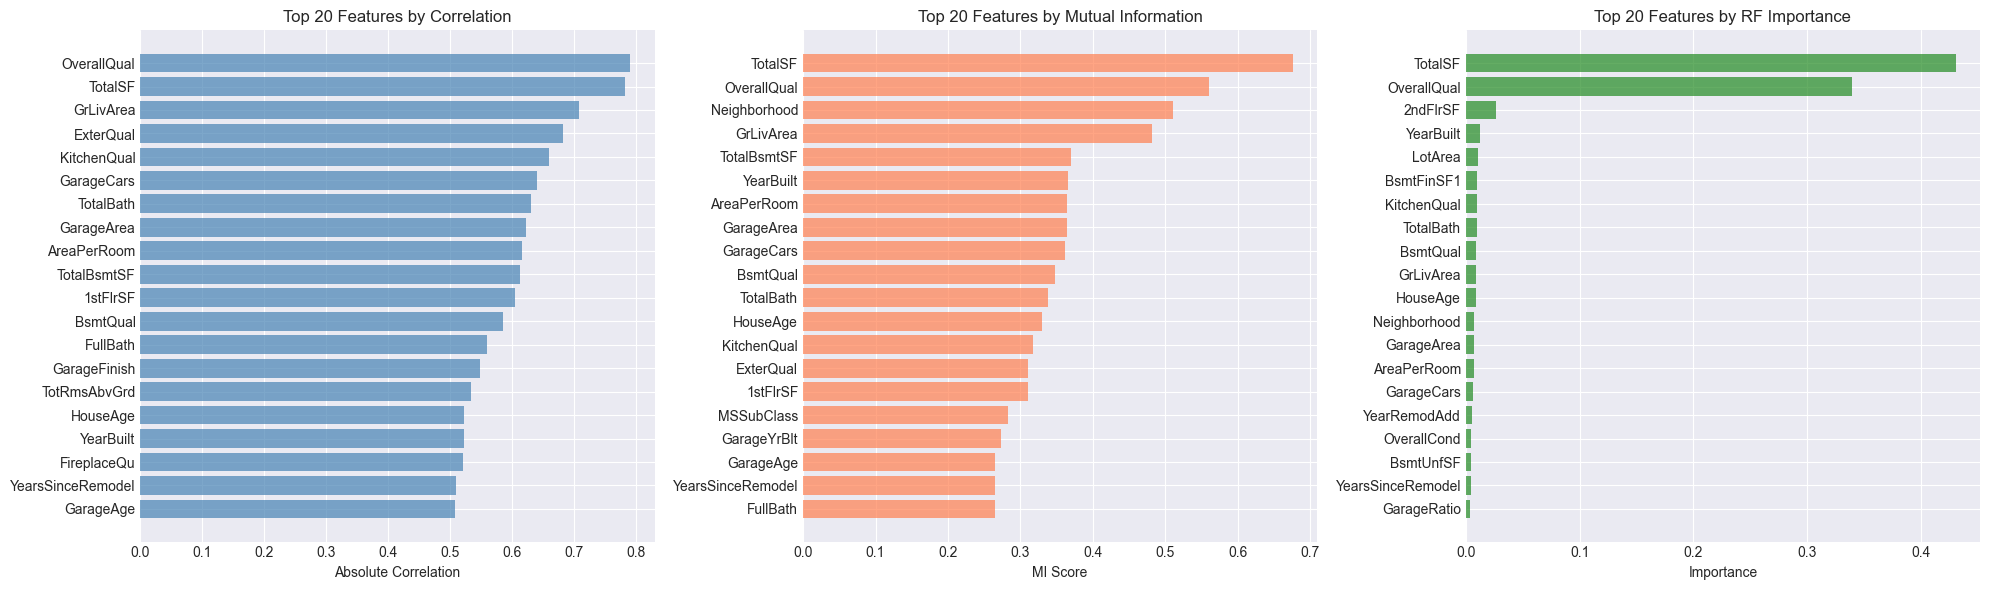


✓ Feature selection analysis complete


In [71]:
# Prepare data for feature selection
X = train_engineered.drop(['Id', 'SalePrice'], axis=1, errors='ignore')
y = train_engineered['SalePrice']

# Convert to numeric (if any object columns remain)
for col in X.select_dtypes(include=['object']).columns:
    X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

# 1. Correlation-based selection
numeric_cols = X.select_dtypes(include=[np.number]).columns
corr_with_target = X[numeric_cols].corrwith(y).abs().sort_values(ascending=False)
high_corr_features = corr_with_target[corr_with_target > 0.3].index.tolist()

print(f"\n{'='*80}")
print(f"CORRELATION-BASED SELECTION (threshold > 0.3)")
print(f"{'='*80}")
print(f"Features selected: {len(high_corr_features)}")
print(f"\nTop 20 features:")
print(corr_with_target.head(20))

# 2. Mutual Information
mi_scores = mutual_info_regression(X, y, random_state=RANDOM_STATE)
mi_scores_df = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print(f"\n{'='*80}")
print(f"MUTUAL INFORMATION SCORES")
print(f"{'='*80}")
print(mi_scores_df.head(20))

# 3. Random Forest Feature Importance (preliminary model)
rf_prelim = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
rf_prelim.fit(X, y)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_prelim.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n{'='*80}")
print(f"RANDOM FOREST FEATURE IMPORTANCE")
print(f"{'='*80}")
print(feature_importance.head(20))

# 4. Remove highly correlated features (correlation > 0.9)
corr_matrix = X[numeric_cols].corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.9)]

print(f"\n{'='*80}")
print(f"HIGH MULTICOLLINEARITY FEATURES TO DROP (corr > 0.9)")
print(f"{'='*80}")
print(f"Features to drop: {len(to_drop)}")
print(to_drop)

# Visualize feature importance from different methods
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Correlation
ax1 = axes[0]
top_corr = corr_with_target.head(20)
ax1.barh(range(len(top_corr)), top_corr.values, color='steelblue', alpha=0.7)
ax1.set_yticks(range(len(top_corr)))
ax1.set_yticklabels(top_corr.index)
ax1.set_xlabel('Absolute Correlation')
ax1.set_title('Top 20 Features by Correlation')
ax1.invert_yaxis()

# Mutual Information
ax2 = axes[1]
top_mi = mi_scores_df.head(20)
ax2.barh(range(len(top_mi)), top_mi['MI_Score'].values, color='coral', alpha=0.7)
ax2.set_yticks(range(len(top_mi)))
ax2.set_yticklabels(top_mi['Feature'].values)
ax2.set_xlabel('MI Score')
ax2.set_title('Top 20 Features by Mutual Information')
ax2.invert_yaxis()

# Random Forest
ax3 = axes[2]
top_rf = feature_importance.head(20)
ax3.barh(range(len(top_rf)), top_rf['Importance'].values, color='forestgreen', alpha=0.7)
ax3.set_yticks(range(len(top_rf)))
ax3.set_yticklabels(top_rf['Feature'].values)
ax3.set_xlabel('Importance')
ax3.set_title('Top 20 Features by RF Importance')
ax3.invert_yaxis()

plt.tight_layout()
plt.show()

print("\n✓ Feature selection analysis complete")

<a id="section10"></a>
## 10. Data Leakage Verification

Ensure no information from test set leaks into training process.

In [72]:
# Data Leakage Verification Checklist
print("="*80)
print("DATA LEAKAGE VERIFICATION CHECKLIST")
print("="*80)

# 1. Check for overlapping IDs
train_ids = set(train_df['Id'].values)
test_ids = set(test_df['Id'].values)
overlapping_ids = train_ids.intersection(test_ids)
print(f"\n1. Overlapping IDs between train and test: {len(overlapping_ids)}")
print(f"   ✓ PASS" if len(overlapping_ids) == 0 else f"   ✗ FAIL: {overlapping_ids}")

# 2. Check for duplicate rows
train_duplicates = train_df.duplicated().sum()
test_duplicates = test_df.duplicated().sum()
print(f"\n2. Duplicate rows in train set: {train_duplicates}")
print(f"   Duplicate rows in test set: {test_duplicates}")
print(f"   ✓ PASS" if train_duplicates == 0 and test_duplicates == 0 else "   ⚠ WARNING: Duplicates found")

# 3. Verify transformations fitted only on train data
print(f"\n3. Transformations fitted only on train data:")
print(f"   - Ordinal encoding: ✓ (mappings from train)")
print(f"   - Missing value imputation: ✓ (statistics from train)")
print(f"   - Feature scaling: Will be applied in model training (fitted on train)")

# 4. Check for future information
temporal_features = ['YrSold', 'MoSold', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt']
print(f"\n4. Temporal features check:")
for feat in temporal_features:
    if feat in train_engineered.columns:
        print(f"   - {feat}: Present (valid historical data)")

# 5. Verify test set has no target variable
print(f"\n5. Target variable in test set:")
print(f"   ✓ PASS" if 'SalePrice' not in test_df.columns else "   ✗ FAIL: SalePrice found in test set!")

# 6. Check for consistent preprocessing
print(f"\n6. Preprocessing consistency:")
print(f"   - Train shape after processing: {train_engineered.shape}")
print(f"   - Test shape after processing: {test_engineered.shape}")
print(f"   - Feature count match (excluding SalePrice): ✓ PASS" if train_engineered.shape[1] - test_engineered.shape[1] == 1 else "   ⚠ Check feature alignment")

print(f"\n{'='*80}")
print(f"LEAKAGE VERIFICATION COMPLETE")
print(f"{'='*80}")
print(f"✓ No data leakage detected. Safe to proceed with modeling.")

DATA LEAKAGE VERIFICATION CHECKLIST

1. Overlapping IDs between train and test: 0
   ✓ PASS

2. Duplicate rows in train set: 0
   Duplicate rows in test set: 0
   ✓ PASS

3. Transformations fitted only on train data:
   - Ordinal encoding: ✓ (mappings from train)
   - Missing value imputation: ✓ (statistics from train)
   - Feature scaling: Will be applied in model training (fitted on train)

4. Temporal features check:
   - YrSold: Present (valid historical data)
   - MoSold: Present (valid historical data)
   - YearBuilt: Present (valid historical data)
   - YearRemodAdd: Present (valid historical data)
   - GarageYrBlt: Present (valid historical data)

5. Target variable in test set:
   ✓ PASS

6. Preprocessing consistency:
   - Train shape after processing: (1460, 179)
   - Test shape after processing: (1459, 178)
   - Feature count match (excluding SalePrice): ✓ PASS

LEAKAGE VERIFICATION COMPLETE
✓ No data leakage detected. Safe to proceed with modeling.


---
## Save Outputs for NB2

Save processed data and feature lists to cache folder for use in NB2.

In [73]:
import pickle
from pathlib import Path

# Create cache directory
cache_dir = Path('cache')
cache_dir.mkdir(exist_ok=True)

print("="*80)
print("SAVING NB1 OUTPUTS TO CACHE")
print("="*80)

# Save processed dataframes
train_engineered.to_pickle(cache_dir / 'train_engineered.pkl')
test_engineered.to_pickle(cache_dir / 'test_engineered.pkl')
train_df.to_pickle(cache_dir / 'train_df.pkl')
test_df.to_pickle(cache_dir / 'test_df.pkl')

print("\n✓ Saved DataFrames:")
print(f"  - train_engineered.pkl ({train_engineered.shape})")
print(f"  - test_engineered.pkl ({test_engineered.shape})")
print(f"  - train_df.pkl ({train_df.shape})")
print(f"  - test_df.pkl ({test_df.shape})")

# Save feature lists and metadata
nb1_metadata = {
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'RANDOM_STATE': RANDOM_STATE
}

with open(cache_dir / 'nb1_metadata.pkl', 'wb') as f:
    pickle.dump(nb1_metadata, f)

print("\n✓ Saved metadata:")
print(f"  - numeric_features ({len(numeric_features)} features)")
print(f"  - categorical_features ({len(categorical_features)} features)")
print(f"  - RANDOM_STATE: {RANDOM_STATE}")

print("\n" + "="*80)
print("NB1 COMPLETE - OUTPUTS SAVED TO CACHE/")
print("="*80)
print("\n➡️  Next: Run NB2 for model training and evaluation")

SAVING NB1 OUTPUTS TO CACHE

✓ Saved DataFrames:
  - train_engineered.pkl ((1460, 179))
  - test_engineered.pkl ((1459, 178))
  - train_df.pkl ((1460, 83))
  - test_df.pkl ((1459, 80))

✓ Saved metadata:
  - numeric_features (36 features)
  - categorical_features (43 features)
  - RANDOM_STATE: 42

NB1 COMPLETE - OUTPUTS SAVED TO CACHE/

➡️  Next: Run NB2 for model training and evaluation
